# RR1/RR3 protocol-robust response comparison

This notebook asks what survives technical remeasurement in RR1 and how that compares with RR3-39 and RR3-40. Every response is **mean(FLT) − mean(GC)**. It reuses matched animals and frozen outputs; BridgeRNA inference and Integrated Gradients were not rerun.

“Robust” below means concordant across the specified original/remeasurement pair. It does **not** mean protocol-independent, causal, or independently biologically replicated.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == 'rr1_rr3_robust_response_comparison': ROOT = ROOT.parents[1]
B = ROOT/'benchmarks/rr1_rr3_robust_response_comparison'
R = B/'results'
pd.set_option('display.max_colwidth', 100)
print('Benchmark:', B)

Benchmark: /home/walt/bridge-rna/benchmarks/rr1_rr3_robust_response_comparison


## 1. Cohorts and exact technical counterparts

RR1 compares OSD-48 with OSD-168; RR3 compares the matched 39-day and 40-day OSD-137 strata with OSD-168. The table below records sample counts, animals, library preparation, sequencing configuration, preservation, strain, sex, and RIN where available. These are technical remeasurements of matched biological material—not new biological replicates.

In [2]:
meta = pd.read_csv(R/'manifest/cohort_metadata_summary.csv')
display(meta.style.hide(axis='index').format({'RIN_median':'{:.2f}','RIN_min':'{:.2f}','RIN_max':'{:.2f}'}, na_rep='—'))
animals = pd.read_csv(R/'manifest/exact_matched_animals.csv')
display(animals.groupby(['cohort','measurement','OSD','condition']).agg(n=('sample_id','nunique'), animals=('animal_id', lambda x: ', '.join(x))).reset_index().style.hide(axis='index'))

cohort,OSD,condition,n,animal_ids,library_preparation,sequencing_configuration,sequencing_facility,preservation,strain,sex,RIN_median,RIN_min,RIN_max
RR1 Ribo remeasurement,OSD-168,FLT,4,M25; M26; M28; M30,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,C57BL/6J,Female,9.05,8.10,9.10
RR1 Ribo remeasurement,OSD-168,GC,5,M36; M37; M38; M39; M40,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,C57BL/6J,Female,8.00,7.90,9.20
RR1 carcass,OSD-48,FLT,4,M25; M26; M28; M30,polyA,SE 50bp 30M,UC Davis,Mini Cold Bag to -80C freezer,C57BL/6J,Female,8.55,7.70,9.10
RR1 carcass,OSD-48,GC,5,M36; M37; M38; M39; M40,polyA,SE 50bp 30M,UC Davis,Mini Cold Bag to -80C freezer,C57BL/6J,Female,8.00,7.90,9.20
RR3-39,OSD-137,FLT,2,F1; F2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.30,7.30,7.30
RR3-39,OSD-137,GC,2,G1; G2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.20,7.10,7.30
RR3-39 technical remeasurement,OSD-168,FLT,2,F1; F2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.30,7.30,7.30
RR3-39 technical remeasurement,OSD-168,GC,2,G1; G2,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.20,7.10,7.30
RR3-40,OSD-137,FLT,2,F3; F4,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.10,6.70,7.50
RR3-40,OSD-137,GC,2,G3; G5,ribodepleted,PE 150bp 100M,UC Davis,Liquid Nitrogen,BALB/c,Female,7.35,6.90,7.80


cohort,measurement,OSD,condition,n,animals
RR1,original,OSD-48,FLT,4,"M25, M26, M28, M30"
RR1,original,OSD-48,GC,5,"M36, M37, M38, M39, M40"
RR1,remeasure,OSD-168,FLT,4,"M25, M26, M28, M30"
RR1,remeasure,OSD-168,GC,5,"M36, M37, M38, M39, M40"
RR3-39,original,OSD-137,FLT,2,"F1, F2"
RR3-39,original,OSD-137,GC,2,"G1, G2"
RR3-39,remeasure,OSD-168,FLT,2,"F1, F2"
RR3-39,remeasure,OSD-168,GC,2,"G1, G2"
RR3-40,original,OSD-137,FLT,2,"F3, F4"
RR3-40,original,OSD-137,GC,2,"G3, G5"


## 2. Primary comparison

The same definitions are used for all cohorts. Expression and signed IG robustness require mutual Top-500 membership and concordant sign. Graph robustness uses a positive Top-500 per-gene neighborhood-response cosine. Counts supported by ≥2 or all 3 evidence levels are intersections of these prespecified indicators, not learned scores.

In [3]:
primary = pd.read_csv(R/'summary/primary_comparison.csv', index_col=0)
display(primary.style.format('{:.3f}', na_rep='—'))

,RR1,RR3-39,RR3-40
metric,,,
3-level genes,26.000,15.000,31.000
Expression Spearman,0.425,0.618,0.673
Expression cosine,0.369,0.652,0.822
Global response cosine,-0.807,0.790,0.917
Graph response cosine,0.183,0.319,0.399
Hallmark cosine,-0.424,0.775,0.922
IG Spearman,0.194,0.601,0.597
IG cosine,0.727,0.867,0.725
Median local graph cosine,0.138,0.340,0.386


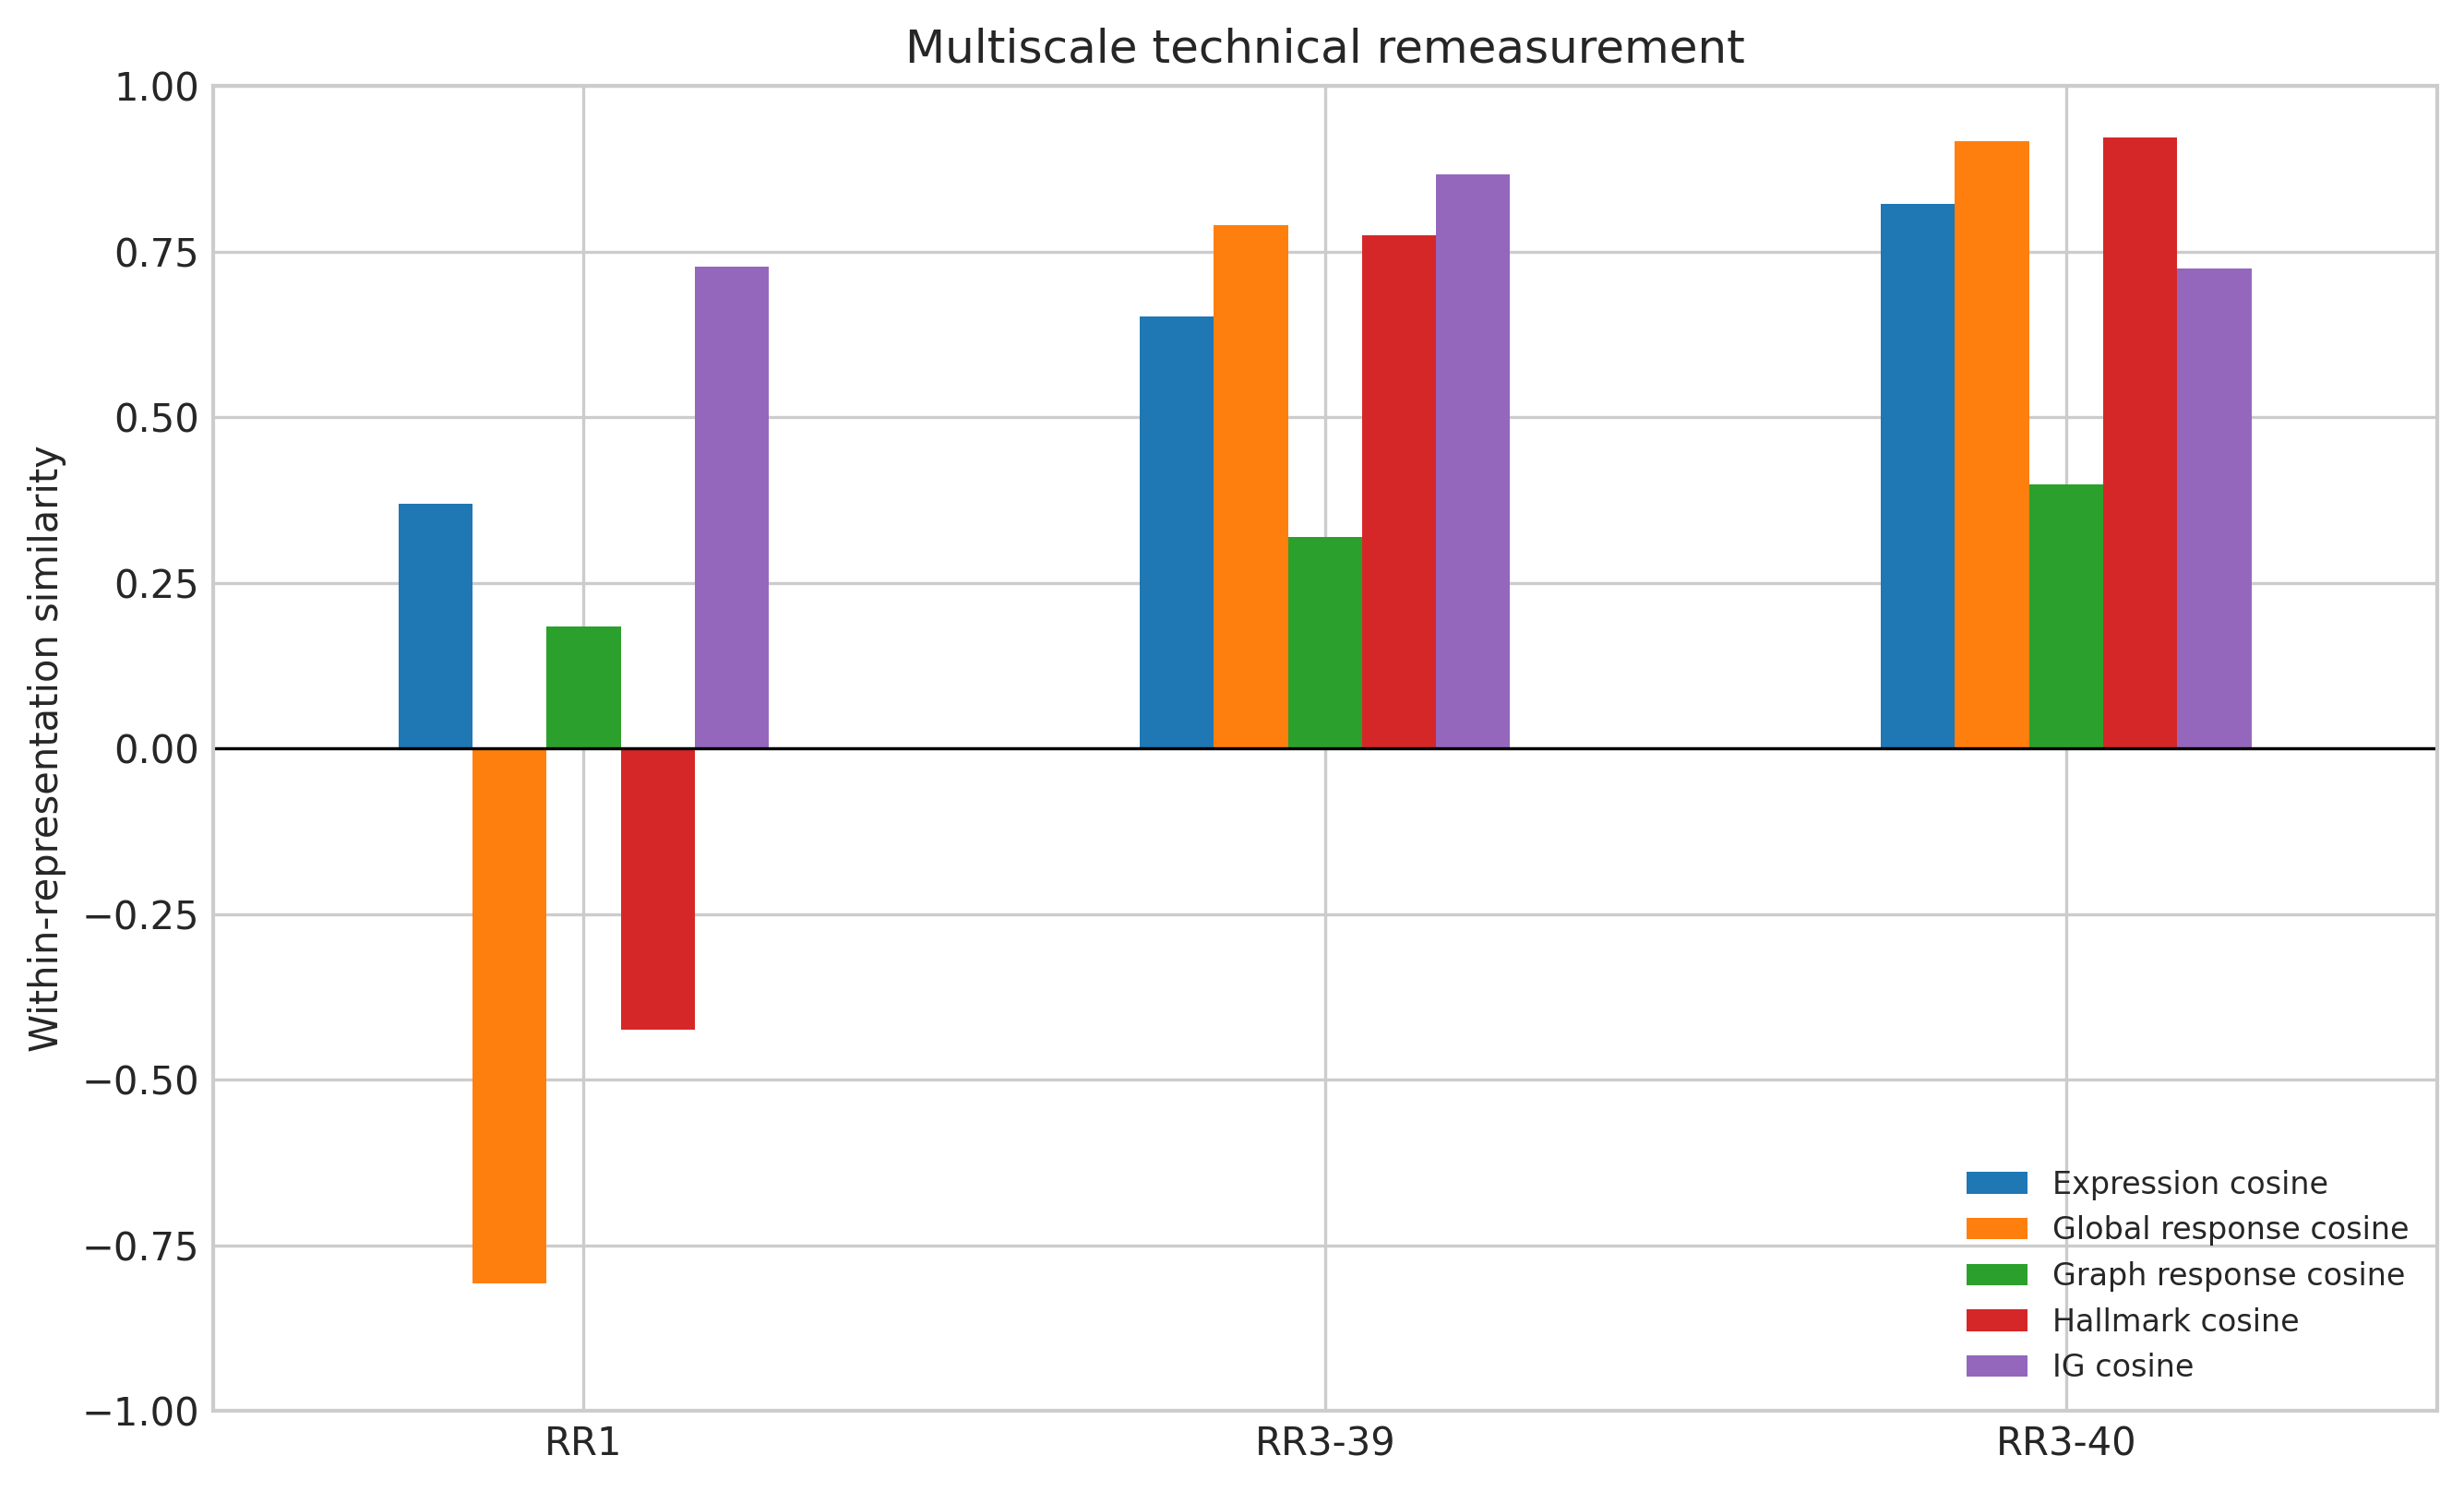

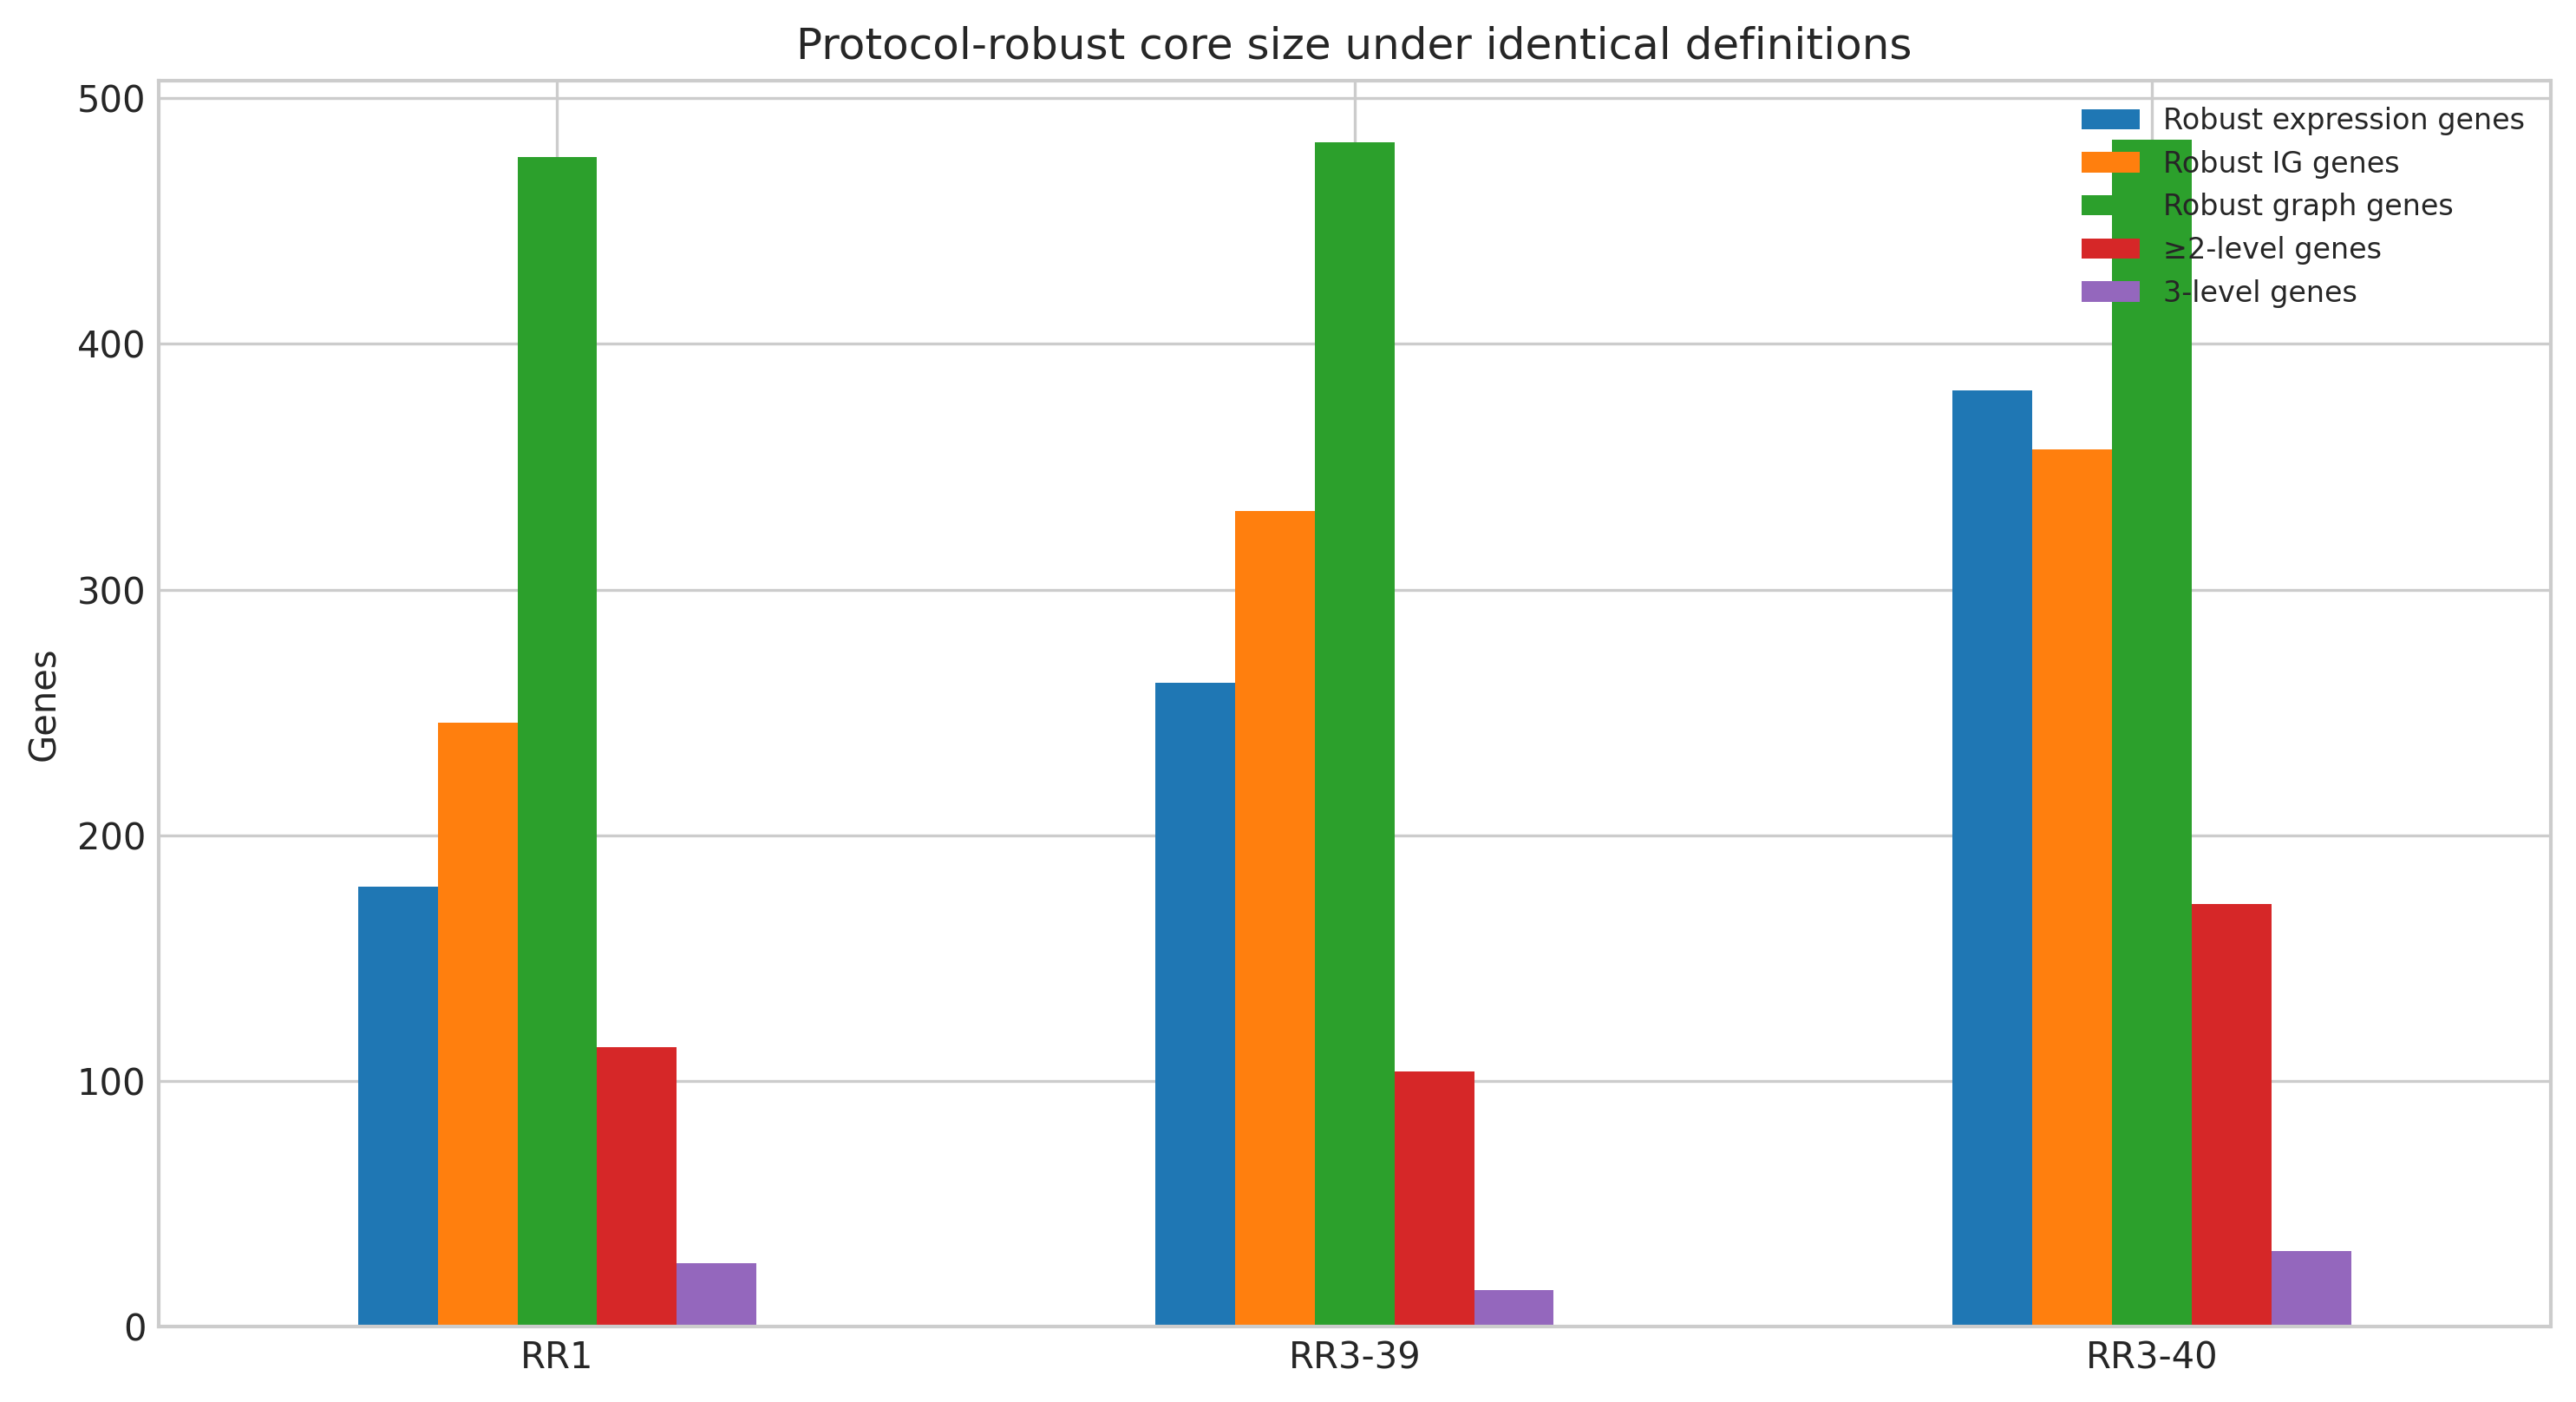

In [4]:
display(Image(filename=str(R/'figures/multiscale_reproducibility.png'), width=900))
display(Image(filename=str(R/'figures/robust_core_size.png'), width=900))

**Headline.** RR3-40 is the strongest technical replication: global response cosine 0.917, expression cosine 0.822, Hallmark cosine 0.922, and 172 genes supported by at least two levels. RR3-39 is moderate/good. RR1 reverses globally (−0.807) and at the Hallmark level (−0.424), with weaker expression, IG-rank, and local-graph agreement. Nevertheless, RR1 retains a restricted 114-gene ≥2-level core and 26 genes supported at all three levels.

RR1's signed IG cosine (0.727) should not be read alone: its low IG Spearman (0.194) shows extensive rank reweighting. Cosine can remain positive when a shared high-magnitude component dominates.

## 3. Expression and attribution robustness

Top-N overlap and genome-wide direction agreement complement correlation. The scatter plot highlights the all-three-level genes and the largest expression interactions.

cohort,pearson,spearman,cosine,genome_direction_agreement,level,median_local_cosine,positive_local_fraction
RR1,0.645,0.425,0.369,0.464,expression,—,—
RR1,0.735,0.194,0.727,0.480,attribution,—,—
RR1,—,—,—,—,graph_local,0.138,0.757
RR3-39,0.646,0.618,0.652,0.710,expression,—,—
RR3-39,0.866,0.601,0.867,0.712,attribution,—,—
RR3-39,—,—,—,—,graph_local,0.340,0.830
RR3-40,0.823,0.673,0.822,0.710,expression,—,—
RR3-40,0.725,0.597,0.725,0.694,attribution,—,—
RR3-40,—,—,—,—,graph_local,0.386,0.840


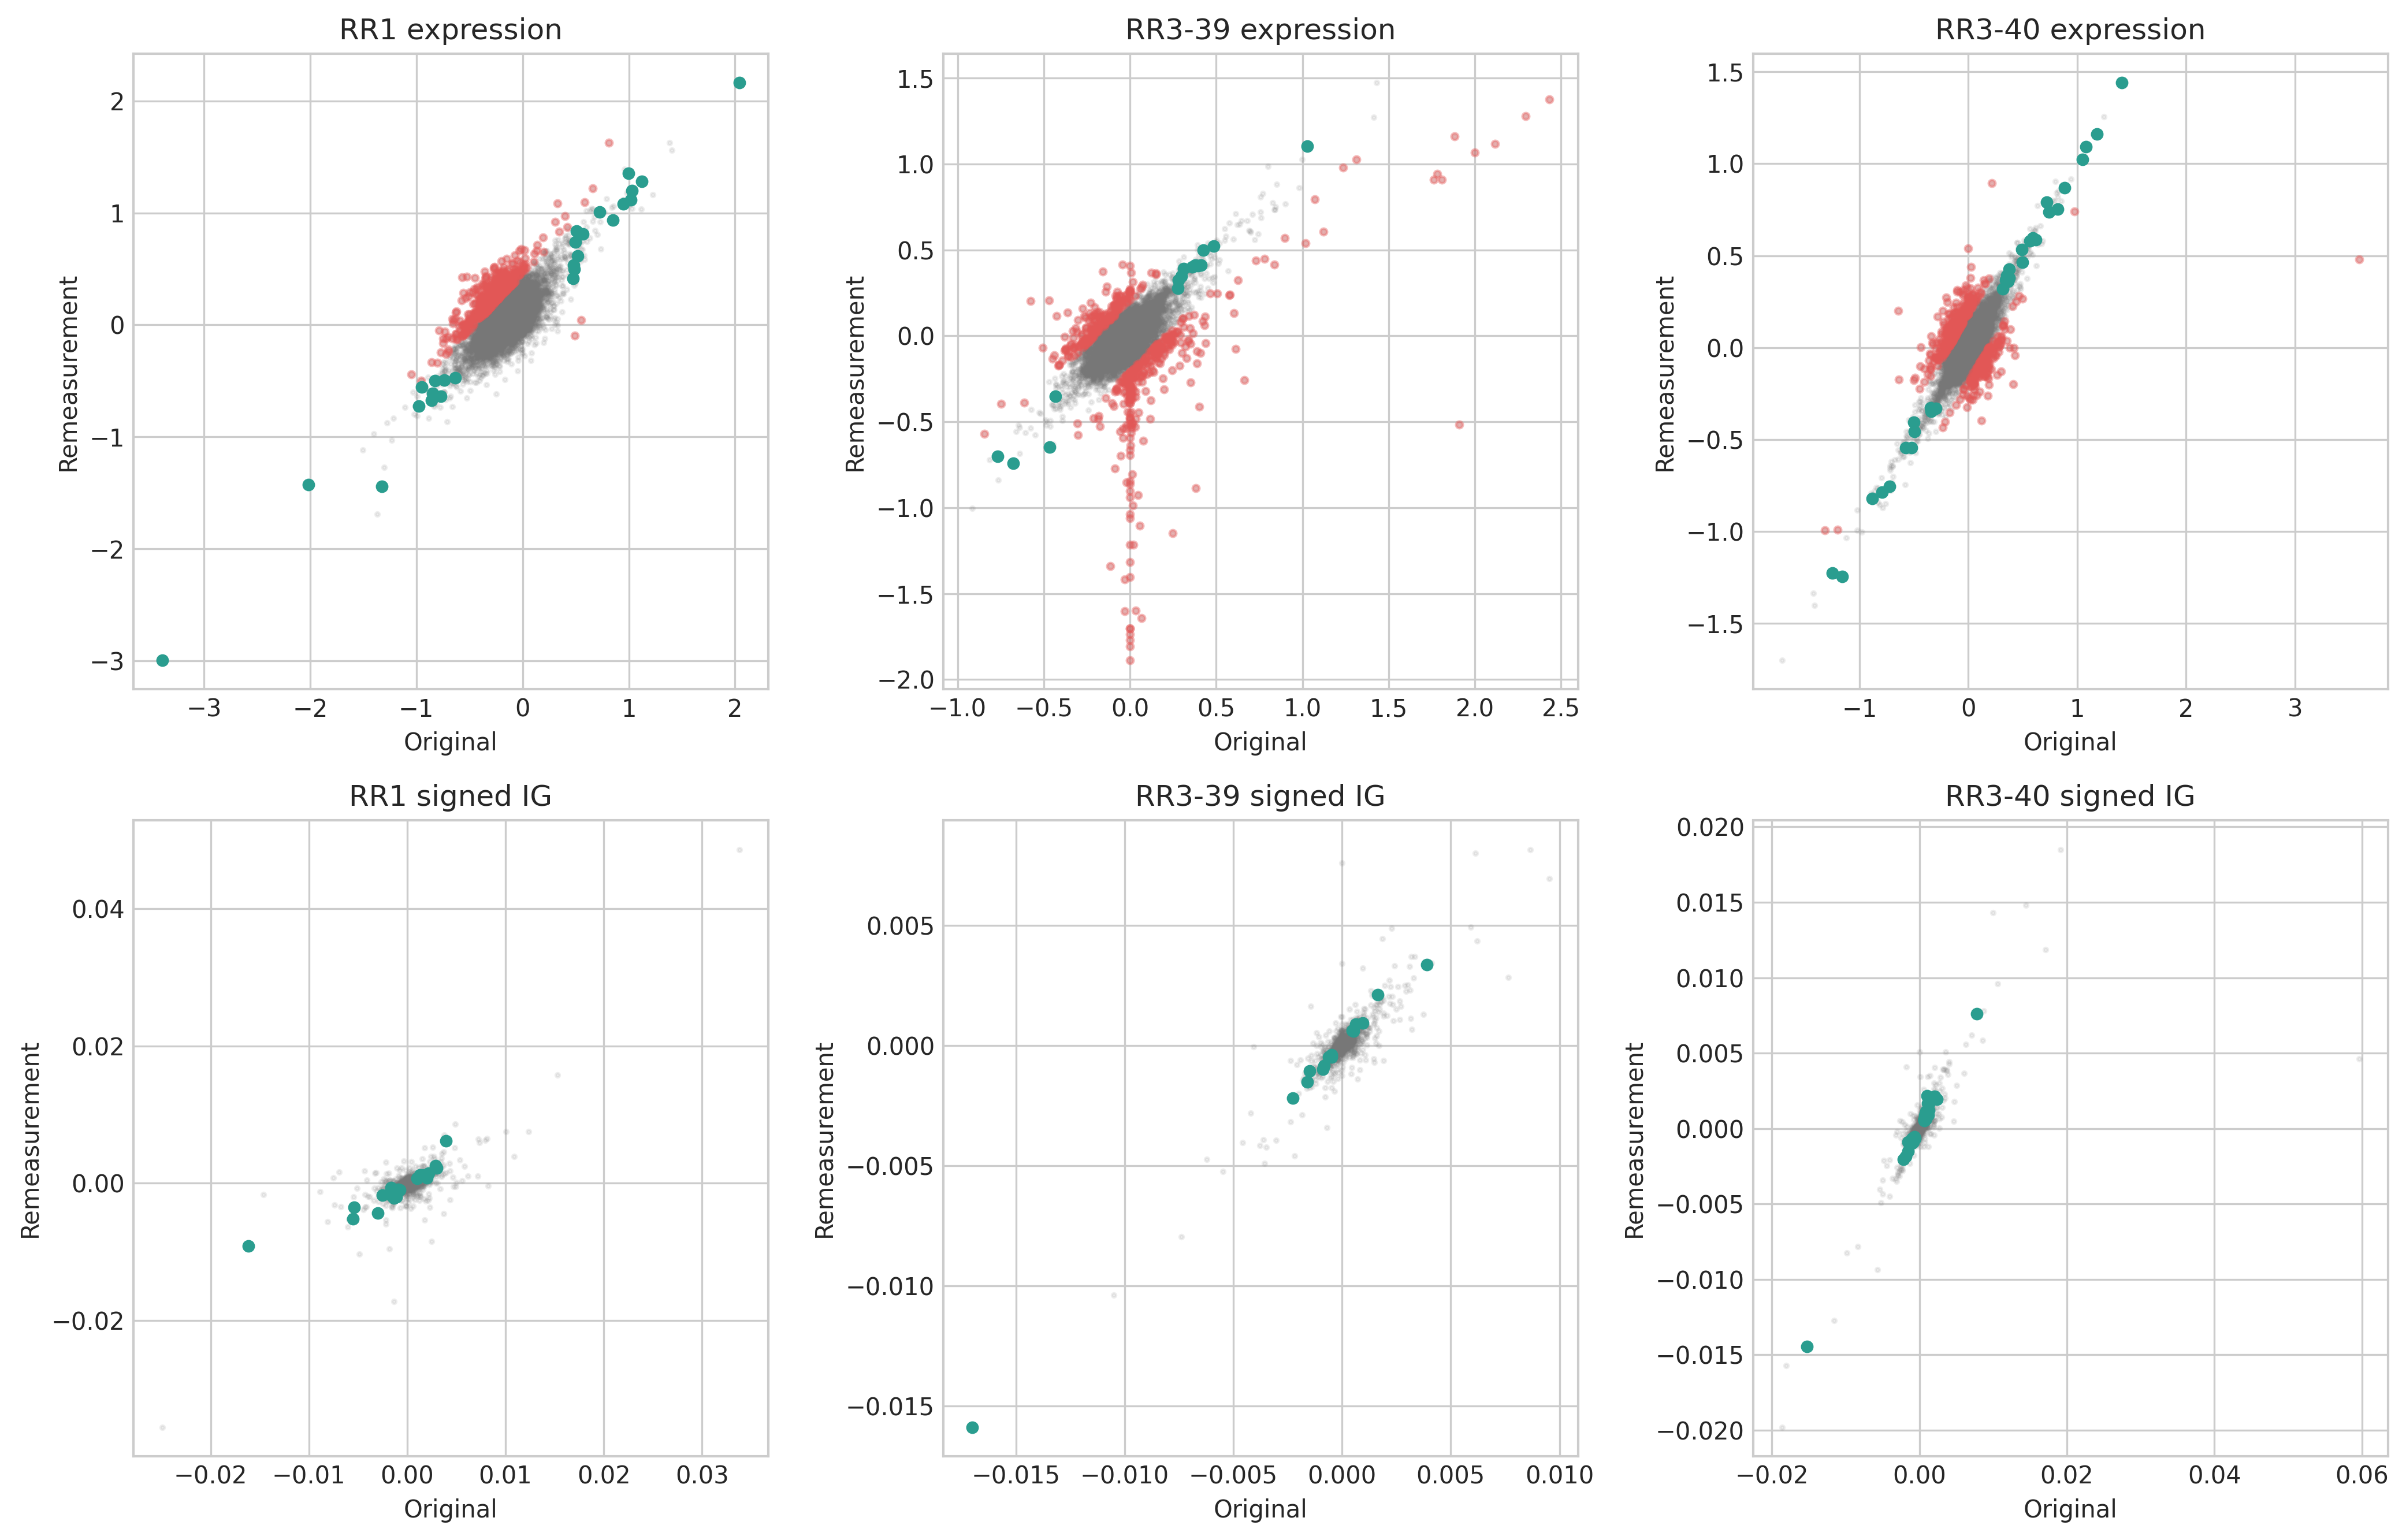

In [5]:
topn = pd.read_csv(ROOT/'benchmarks/rr1_library_prep_interaction/results/robust_core/rr3_controls/topn_overlap.csv')
display(topn.pivot_table(index=['level','top_n'], columns='cohort', values=['overlap','direction_agreement']).style.format({'direction_agreement':'{:.1%}'}, na_rep='—'))
repro = pd.read_csv(ROOT/'benchmarks/rr1_library_prep_interaction/results/robust_core/rr3_controls/multilevel_reproducibility.csv')
display(repro.style.hide(axis='index').format(precision=3, na_rep='—'))
display(Image(filename=str(R/'figures/original_vs_remeasurement.png'), width=1100))

## 4. What BridgeRNA adds

Expression supplies the conventional response baseline. IG asks which input genes influence the frozen latent response; contextual graphs ask whether each gene's local learned neighborhood changes reproducibly. These are multiscale confirmations, not proof that BridgeRNA discovered a raw protocol effect.

cohort,RR1,RR3-39,RR3-40
evidence,,,
Attribution only,180,254,224
Expression + attribution,46,61,110
Expression + attribution + graph,26,15,31
Expression only,85,175,232
Graph only,382,424,390


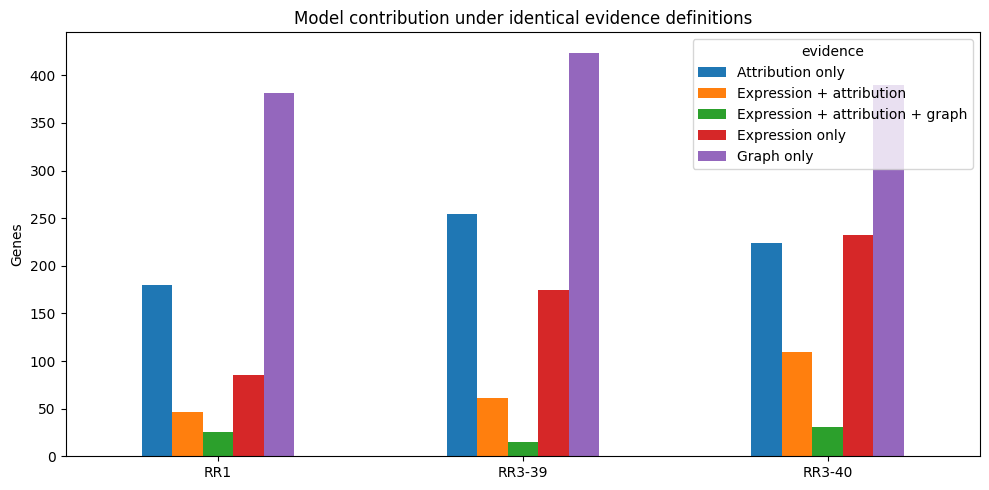

In [6]:
contribution = pd.read_csv(R/'summary/model_contribution.csv')
display(contribution.pivot(index='evidence', columns='cohort', values='genes').fillna(0).astype(int).style)
ax = contribution.pivot(index='cohort', columns='evidence', values='genes').plot.bar(figsize=(10,5))
ax.set(xlabel='', ylabel='Genes', title='Model contribution under identical evidence definitions'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 5. Measurement-sensitive component

For each cohort, `Interaction = ΔX_remeasurement − ΔX_original`; the Top-500 absolute interactions were tested by over-representation analysis against the exact 15,165-gene BridgeRNA universe. These are model-vocabulary expression effects—not a replacement for the existing raw-count edgeR analyses.

In [7]:
sensitive = pd.read_csv(R/'pathways/measurement_sensitive_enrichment.csv')
top_sensitive = (sensitive.query('fdr < 0.05').sort_values(['cohort','fdr']).groupby('cohort').head(8))
display(top_sensitive[['cohort','term','overlap','set_size','fdr']].style.hide(axis='index').format({'fdr':'{:.2e}'}))

cohort,term,overlap,set_size,fdr
RR1,"GO BP: Regulation of mRNA Splicing, via Spliceosome (GO:0048024)",24,98,2.45e-11
RR1,"GO BP: Regulation of Alternative mRNA Splicing, via Spliceosome (GO:0000381)",18,63,1.67e-09
RR1,GO BP: Regulation of RNA Splicing (GO:0043484),21,93,2.22e-09
RR1,GO BP: MRNA Processing (GO:0006397),33,239,2.33e-09
RR1,Reactome: Processing of Capped Intron-Containing Pre-mRNA,32,253,4.23e-08
RR1,Reactome: mRNA Splicing,26,192,4.85e-07
RR1,"GO BP: MRNA Splicing, via Spliceosome (GO:0000398)",27,207,4.85e-07
RR1,"GO BP: RNA Splicing, via Transesterification Reactions With Bulged Adenosine as Nucleophile (GO:0000377)",24,171,8.23e-07
RR3-39,GO BP: Sensory Perception of Light Stimulus (GO:0050953),35,130,2.18e-19
RR3-39,GO BP: Visual Perception (GO:0007601),35,130,2.18e-19


RR1's leading interaction enrichments are consistently **mRNA processing / splicing** terms (FDR down to ~2.3×10⁻¹¹), making this sensitivity especially prominent in RR1. RR3-39 instead has strong light/visual-perception and myogenesis interaction terms; RR3-40 has weaker mitochondrial RNA-processing and immune terms. This does not make RNA processing a pure artifact—it shows that its measured RR1 response is unusually protocol-sensitive.

## 6. T-cell-independent robust pathway core

The primary pathway profile now uses the full signed input-gene IG vectors directly. A pathway is protocol-robust when it is mutually Top-250 by absolute signed-IG pathway score and has concordant sign between the original and remeasurement. No T-cell projection is used.

This yields 125 robust profiles in RR1, 178 in RR3-39, and 200 in RR3-40. **Twenty-two pathways are shared across all three**, replacing the former 29-pathway PC1–2-derived result.

,robust pathways
cohort,
RR1,125
RR3-39,178
RR3-40,200


intersection,RR1,RR3-39,RR3-40,pathways
nan,False,False,False,4795
RR3-39,False,True,False,120
RR3-40,False,False,True,105
RR1 & RR3-40,True,False,True,53
RR1,True,False,False,34
RR1 & RR3-39 & RR3-40,True,True,True,22
RR3-39 & RR3-40,False,True,True,20
RR1 & RR3-39,True,True,False,16


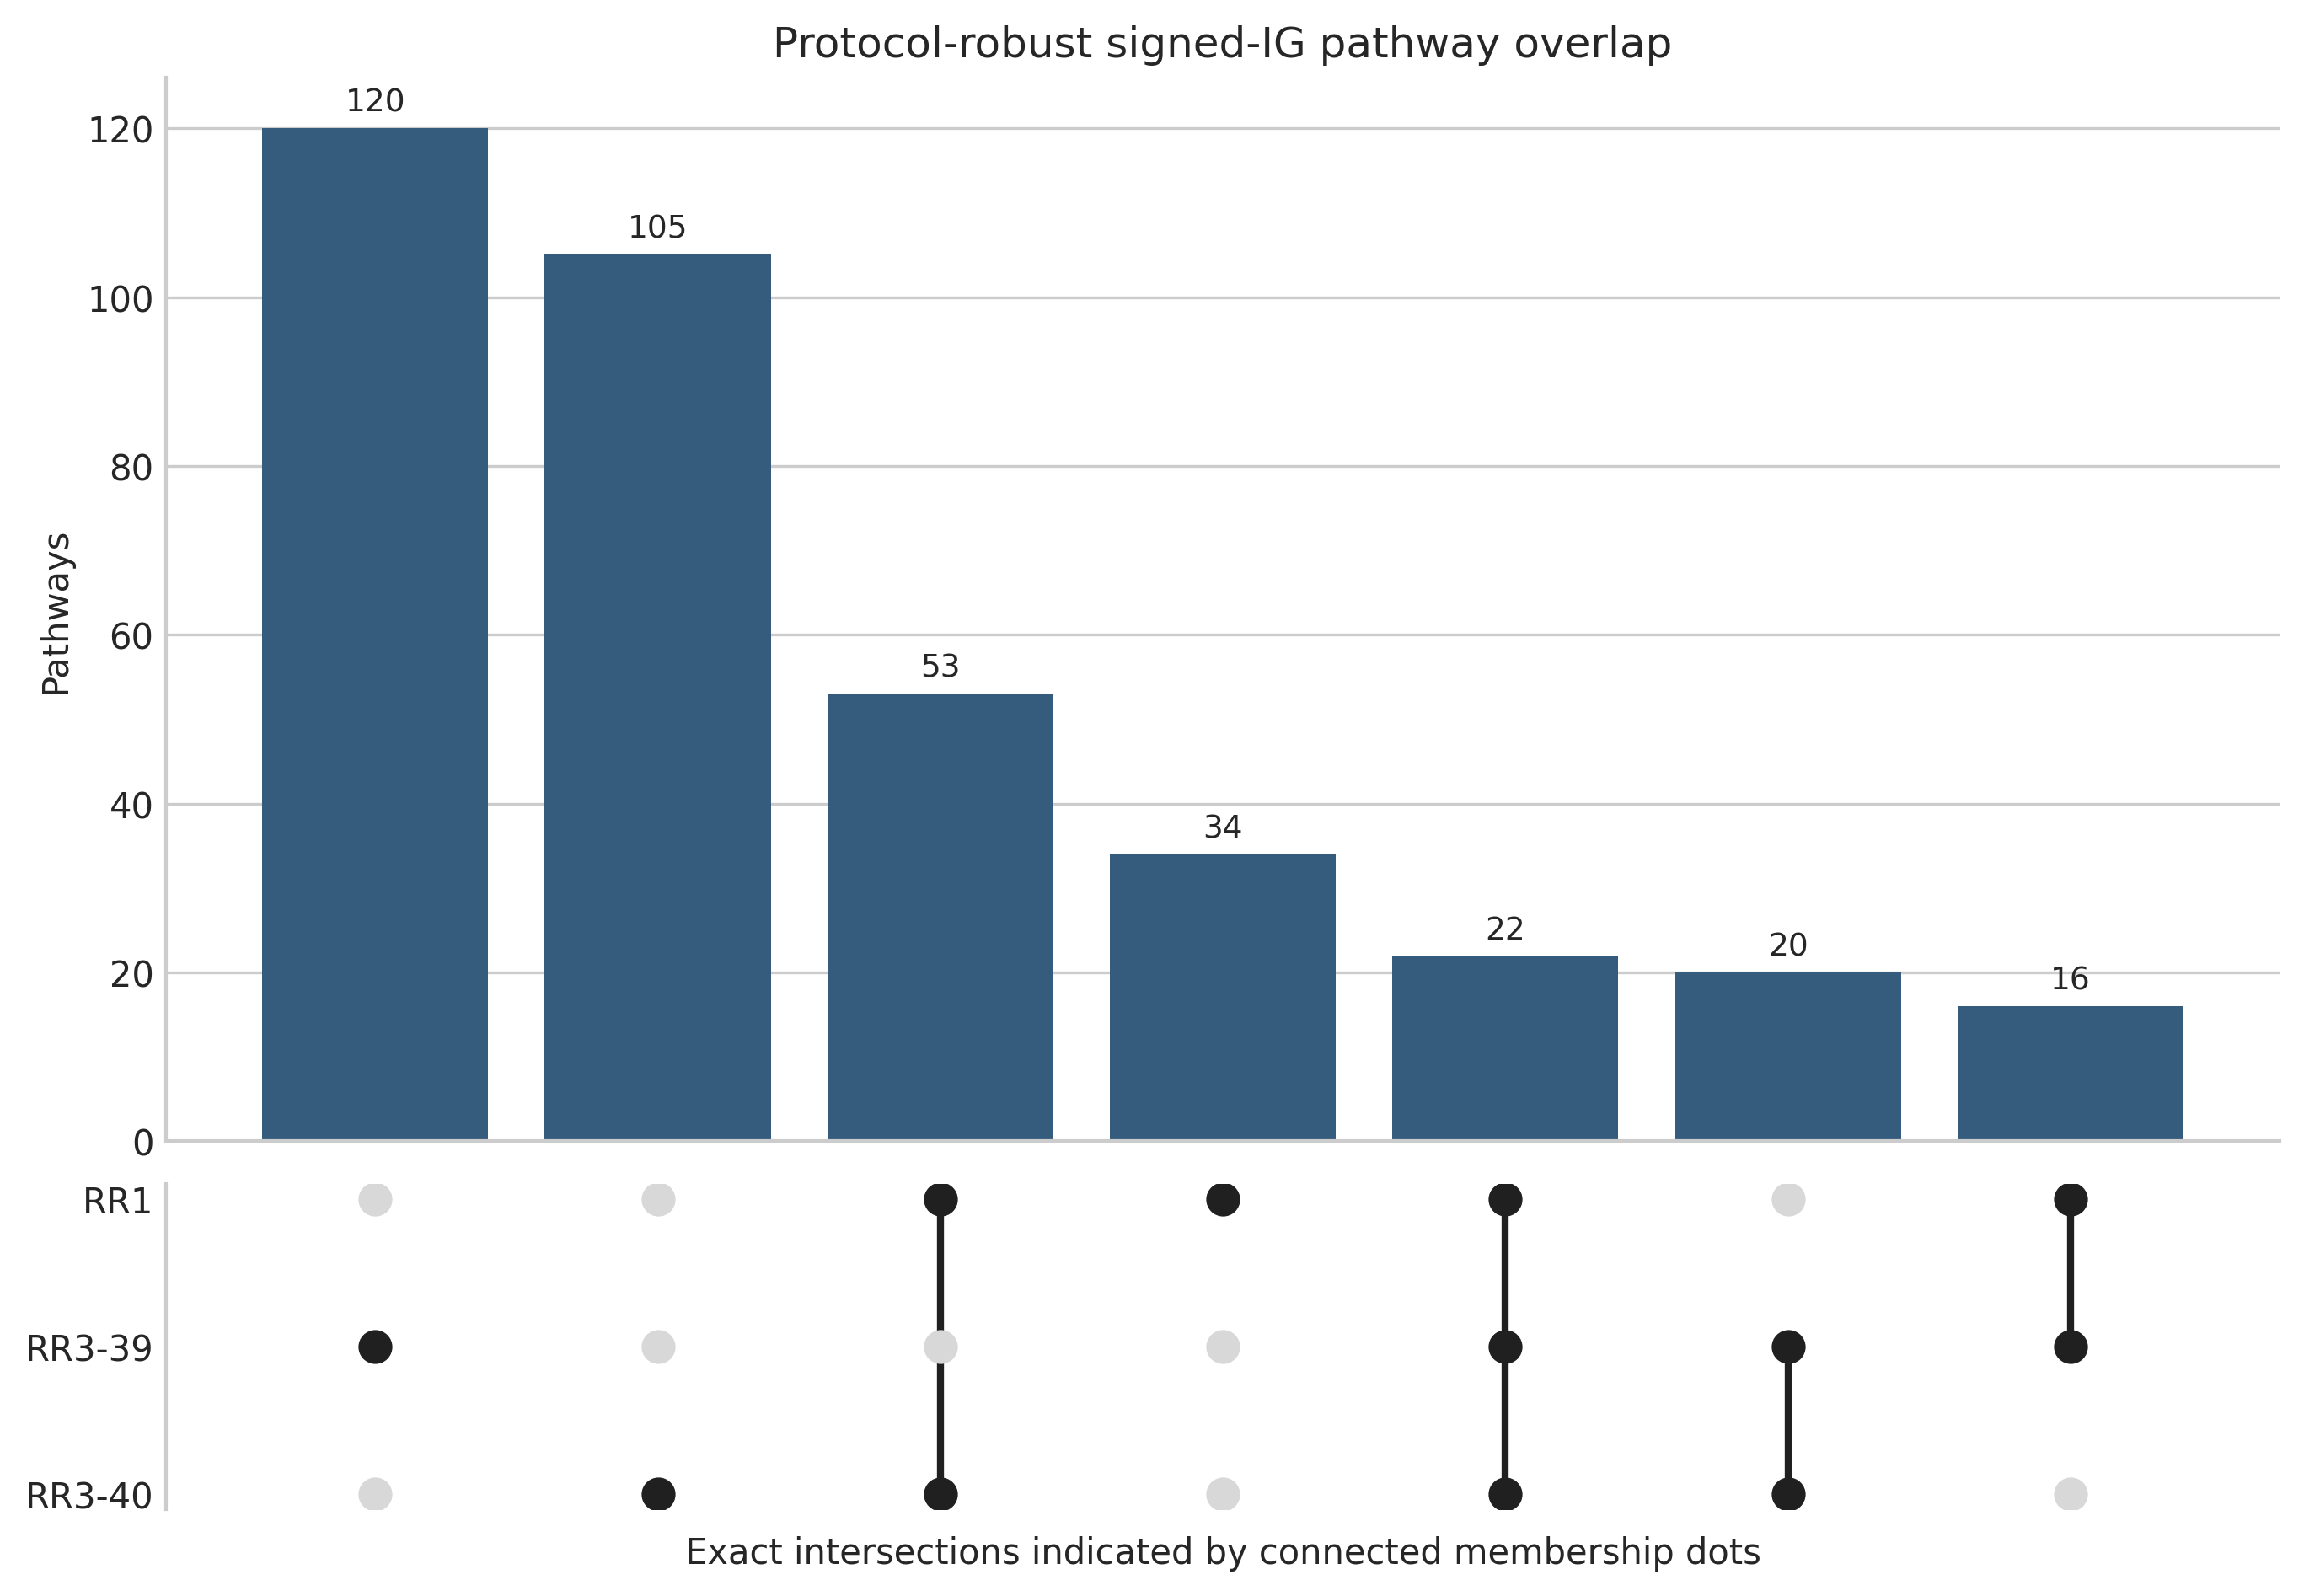

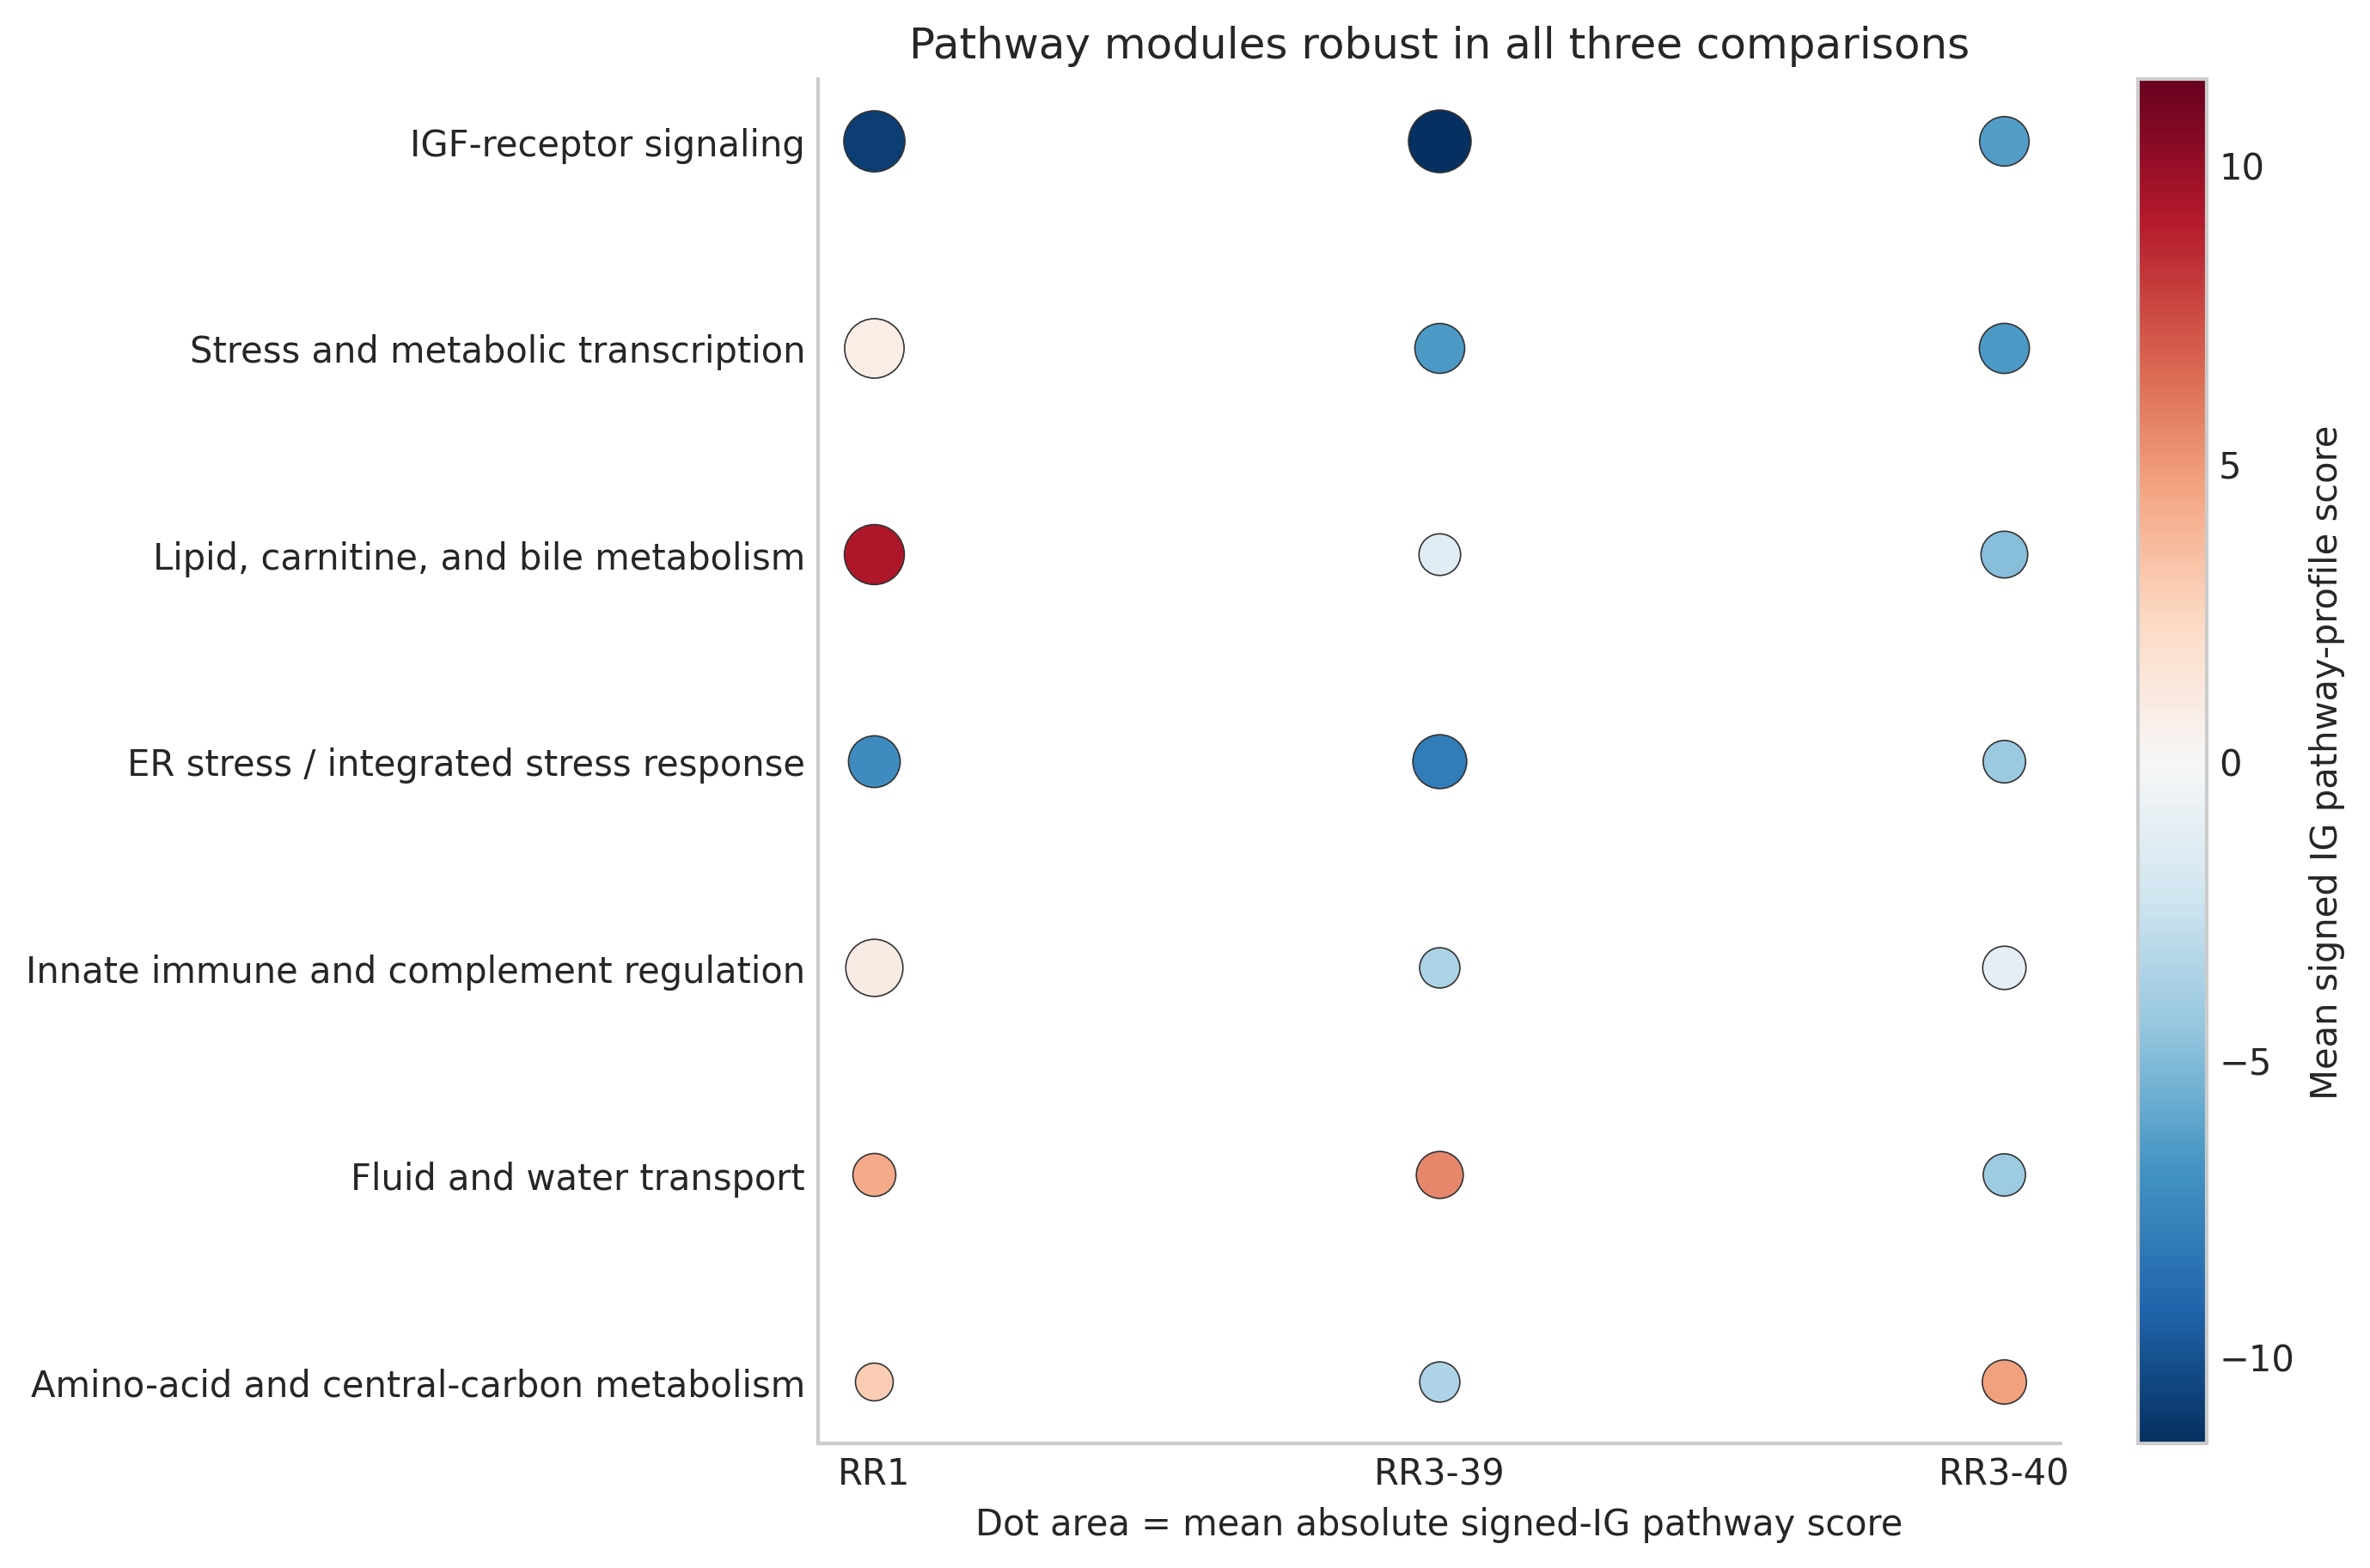

module,source,pathway
"Lipid, carnitine, and bile metabolism",GO:BP,Carnitine Metabolic Process (GO:0009437)
Fluid and water transport,GO:BP,Fluid Transport (GO:0042044)
"Lipid, carnitine, and bile metabolism",GO:BP,Intracellular Lipid Transport (GO:0032365)
Innate immune and complement regulation,GO:BP,Positive Regulation of Immune System Process (GO:0002684)
Innate immune and complement regulation,GO:BP,Positive Regulation of Innate Immune Response (GO:0045089)
Innate immune and complement regulation,GO:BP,Positive Regulation of Response to Biotic Stimulus (GO:0002833)
"Lipid, carnitine, and bile metabolism",GO:BP,Positive Regulation of Triglyceride Metabolic Process (GO:0090208)
IGF-receptor signaling,GO:BP,Regulation of Insulin-Like Growth Factor Receptor Signaling Pathway (GO:0043567)
"Lipid, carnitine, and bile metabolism",GO:BP,Regulation of Lipid Biosynthetic Process (GO:0046890)
Fluid and water transport,GO:BP,Water Transport (GO:0006833)


In [8]:
ind = pd.read_csv(R/'pathways/independent_signed_ig_pathway_classification.csv')
ind_upset = pd.read_csv(R/'summary/independent_pathway_upset_intersections.csv')
ind_core = pd.read_csv(R/'pathways/independent_conserved_core_full.csv')
ind_modules = pd.read_csv(R/'pathways/independent_conserved_core_modules.csv')
display(ind.groupby('cohort').protocol_robust.sum().rename('robust pathways').to_frame().style)
display(ind_upset.query("intersection != 'None'").style.hide(axis='index'))
display(Image(filename=str(R/'figures/independent_robust_pathway_upset.png'), width=900))
display(Image(filename=str(R/'figures/independent_conserved_core_dotplot.png'), width=900))
display(ind_core[['module','source','pathway']].drop_duplicates().style.hide(axis='index'))

The independent 22-pathway core collapses into seven interpretable themes: lipid/carnitine/bile metabolism; amino-acid and central-carbon metabolism; ER/integrated stress; innate immune/complement regulation; stress/metabolic transcription; fluid/water transport; and IGF-receptor signaling. Dot-plot signs describe signed attribution contribution—not pathway up/down regulation.

### Conventional and BridgeRNA support

The matrix separates raw-count edgeR ranked GSEA, enrichment of technically reproducible IG genes, and the robust signed-IG pathway-profile evidence. Scores are scaled within method for color and are never treated as directly comparable units. Because the 22 pathways were selected using the signed-IG pathway profile, that column is true by construction; DE/GSEA and gene-level IG enrichment provide the independent checks.

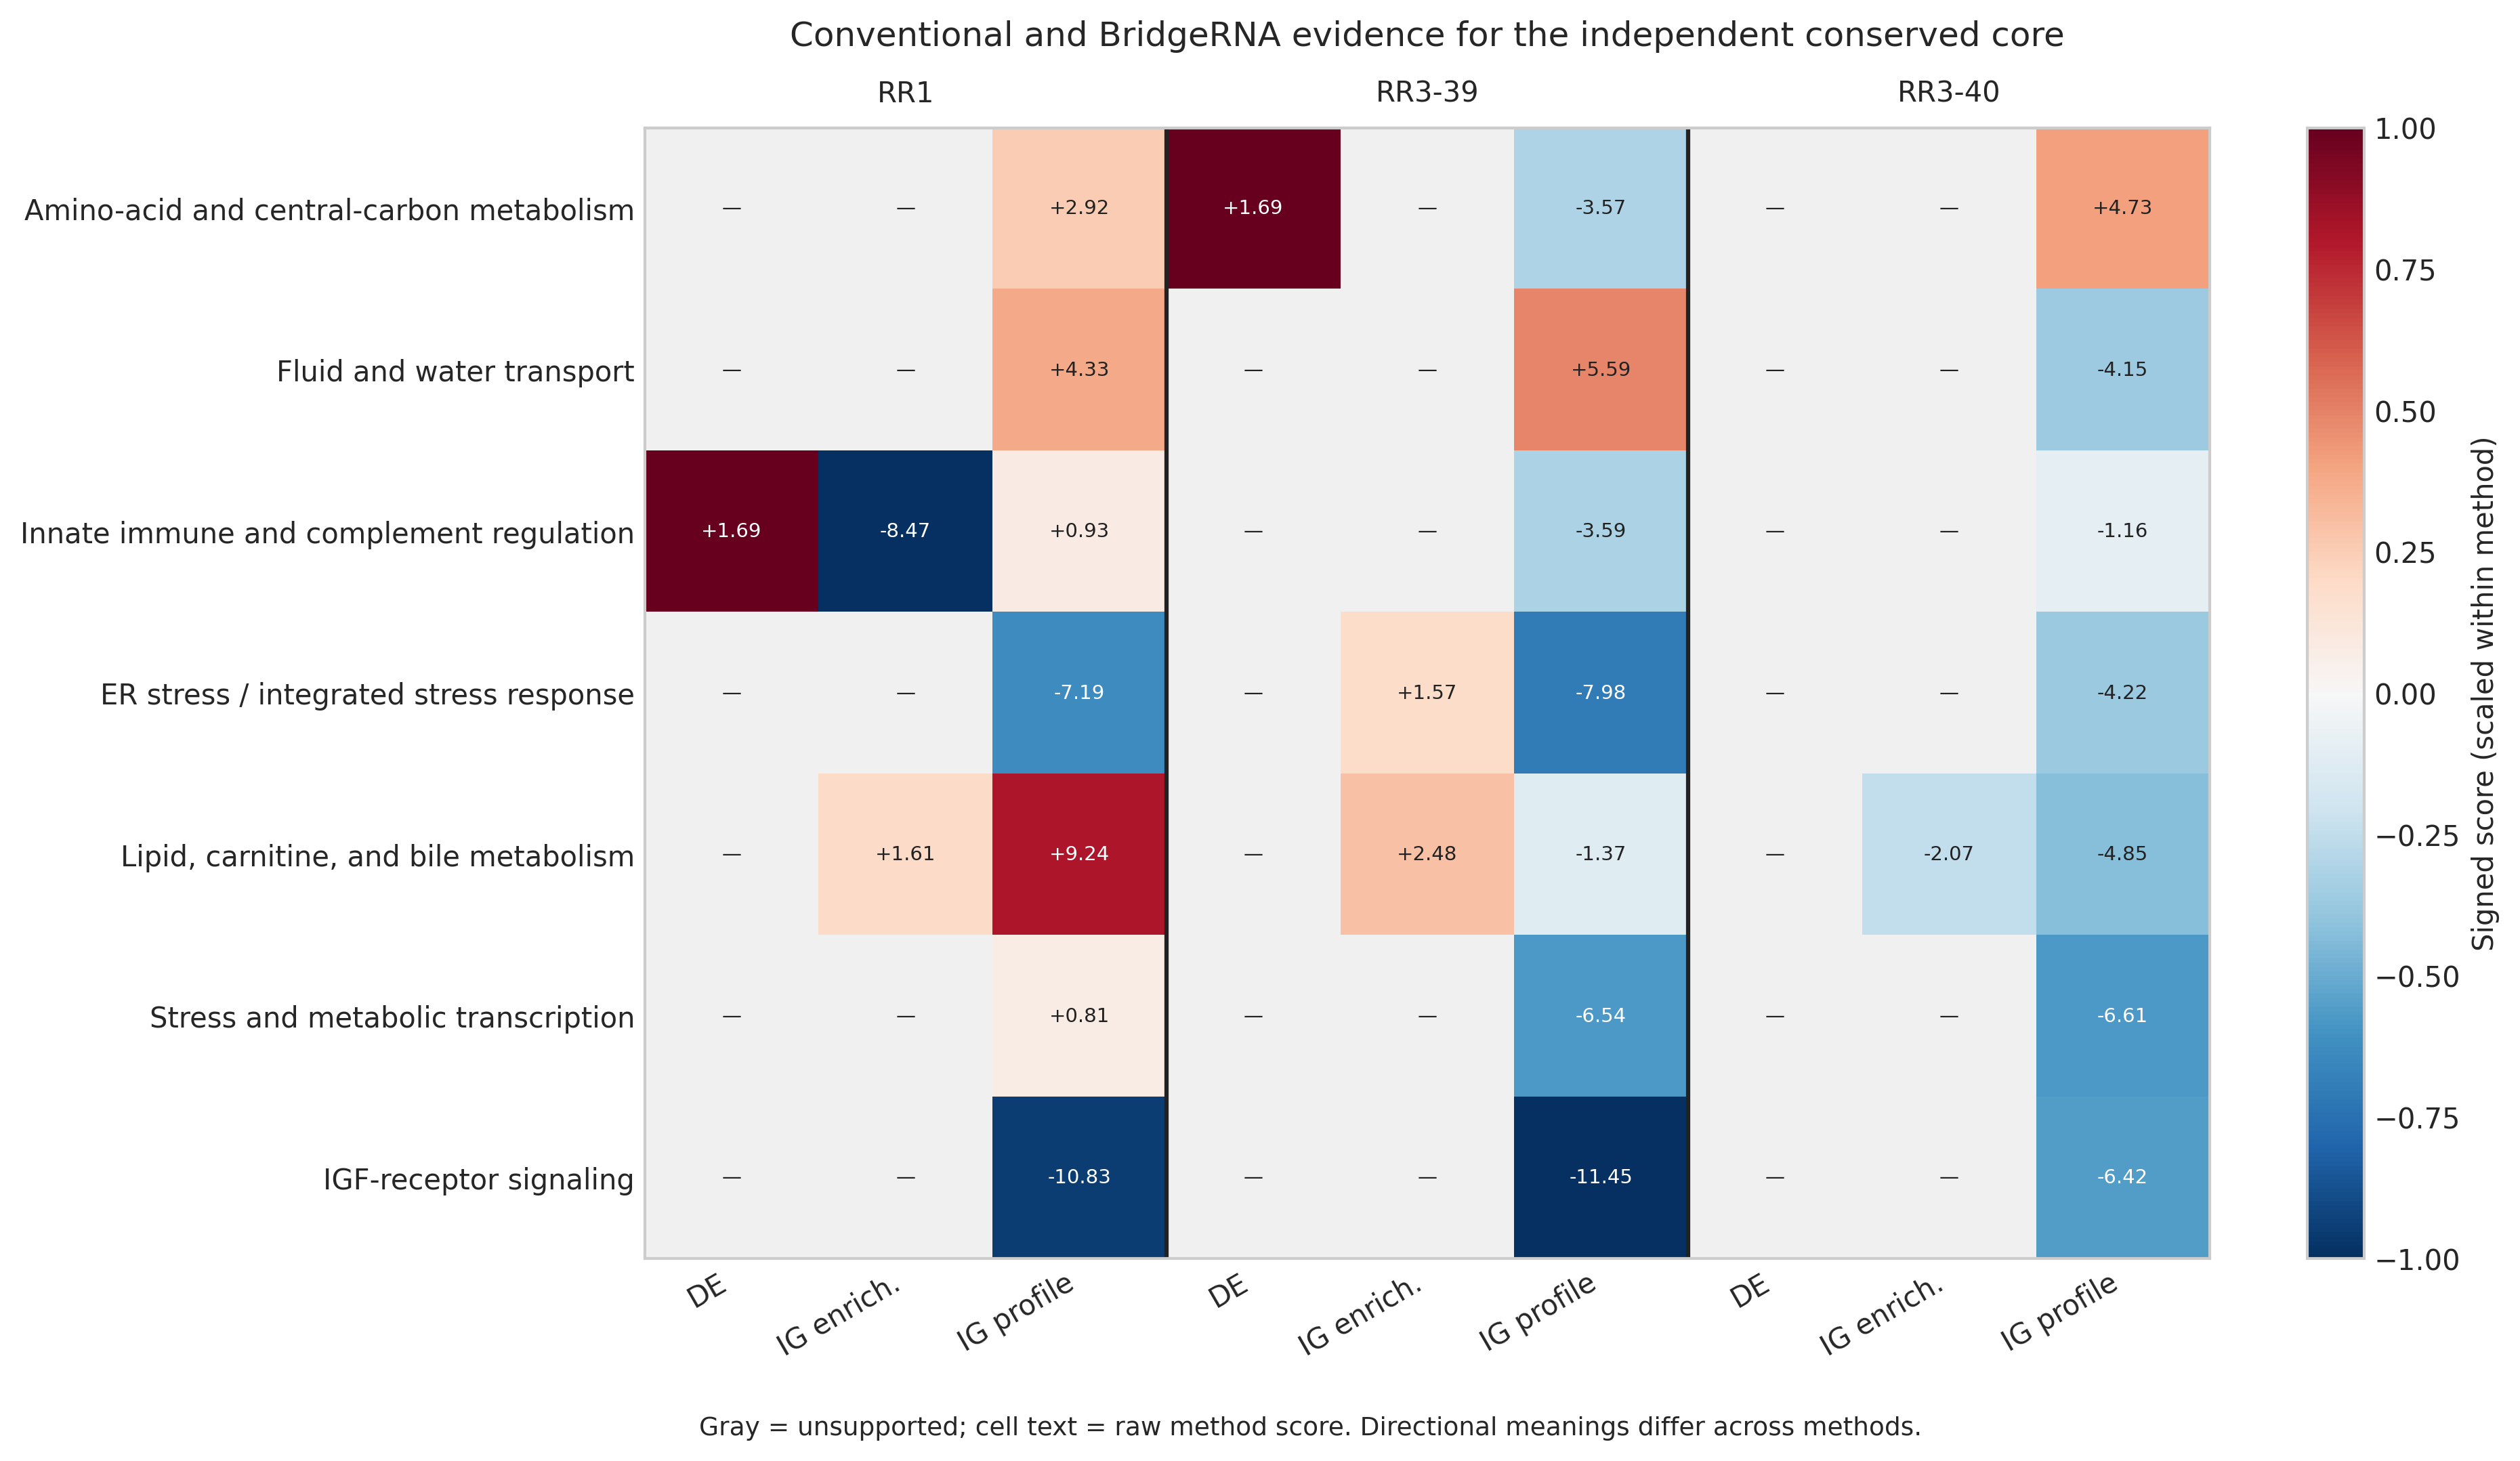

module,cohort,method,support,signed_score,supported_terms,module_terms,direction
Amino-acid and central-carbon metabolism,RR1,DE/GSEA,False,—,0,3,not significant
Amino-acid and central-carbon metabolism,RR1,IG enrichment,False,—,0,3,not significant
Amino-acid and central-carbon metabolism,RR1,Robust signed-IG pathway profile,True,+2.917,3,3,positive contribution
ER stress / integrated stress response,RR1,DE/GSEA,False,—,0,3,not significant
ER stress / integrated stress response,RR1,IG enrichment,False,—,0,3,not significant
ER stress / integrated stress response,RR1,Robust signed-IG pathway profile,True,-7.191,3,3,negative contribution
Fluid and water transport,RR1,DE/GSEA,False,—,0,2,not significant
Fluid and water transport,RR1,IG enrichment,False,—,0,2,not significant
Fluid and water transport,RR1,Robust signed-IG pathway profile,True,+4.333,2,2,positive contribution
IGF-receptor signaling,RR1,DE/GSEA,False,—,0,1,not significant


module,cohort,DE/GSEA,IG enrichment,Robust signed-IG pathway profile,support_count,classification
Amino-acid and central-carbon metabolism,RR1,False,False,True,1,pathway_profile_only
Amino-acid and central-carbon metabolism,RR3-39,True,False,True,2,partial
Amino-acid and central-carbon metabolism,RR3-40,False,False,True,1,pathway_profile_only
ER stress / integrated stress response,RR1,False,False,True,1,pathway_profile_only
ER stress / integrated stress response,RR3-39,False,True,True,2,Bridge_IG_plus_profile
ER stress / integrated stress response,RR3-40,False,False,True,1,pathway_profile_only
Fluid and water transport,RR1,False,False,True,1,pathway_profile_only
Fluid and water transport,RR3-39,False,False,True,1,pathway_profile_only
Fluid and water transport,RR3-40,False,False,True,1,pathway_profile_only
IGF-receptor signaling,RR1,False,False,True,1,pathway_profile_only


In [9]:
three = pd.read_csv(R/'pathways/independent_core_three_method_matrix.csv')
method_overlap = pd.read_csv(R/'summary/independent_core_method_overlap.csv')
display(Image(filename=str(R/'figures/independent_core_three_method_heatmap.png'), width=1150))
display(three.style.hide(axis='index').format({'signed_score':'{:+.3f}'},na_rep='—'))
display(method_overlap.style.hide(axis='index'))

At the collapsed-theme level, conventional support is limited: RR1 supports innate immune/complement regulation and RR3-39 supports amino-acid/central-carbon metabolism. Robust-gene IG enrichment independently supports lipid/carnitine/bile metabolism in all three cohorts; it additionally supports innate immune/complement regulation in RR1 and ER-stress biology in RR3-39. Thus the primary conserved core is BridgeRNA-attribution-derived rather than a restatement of significant conventional GSEA.

Conventional analysis still establishes broader response reproducibility—especially in RR3—and the earlier matched-expression analysis shows exploratory RR1/RR3 opposition. But that opposition is estimator-dependent: matched Δlog1p(TPM) supports it more strongly than full-stratum edgeR. It is therefore retained only as a secondary observation, not a primary pathway conclusion.

### Individual-pathway validation and prior spaceflight evidence

The 22 full signed-IG pathways—not the older T-cell PC1–2-derived set—are checked below against raw-count edgeR ranked GSEA in each cohort. `IG + conventional support` means at least one cohort has exact-pathway GSEA FDR < 0.05. `IG reprioritization` means the pathway was testable in all three cohorts but conventional GSEA was nonsignificant in all three. `Ambiguous` is reserved for incomplete GSEA coverage.

The literature labels are conservative module-level annotations from a focused rodent/spaceflight literature audit. “Potentially novel/hypothesis-generating” means direct evidence was not found in that audit; it is not a formal claim of novelty.

In [10]:
validation = pd.read_csv(R/'pathways/independent_core_pathway_validation.csv')
validation_summary = pd.read_csv(R/'summary/independent_core_pathway_validation_summary.csv')
display(validation_summary.style.hide(axis='index'))
view = validation[['module','pathway','RR1_GSEA_NES','RR1_GSEA_FDR','RR3_39_GSEA_NES','RR3_39_GSEA_FDR','RR3_40_GSEA_NES','RR3_40_GSEA_FDR','GSEA_recurrence','evidence_classification','prior_spaceflight_evidence','interpretation']]
display(view.style.hide(axis='index').format({c:'{:.3f}' for c in ['RR1_GSEA_NES','RR3_39_GSEA_NES','RR3_40_GSEA_NES']}).format({c:'{:.2e}' for c in ['RR1_GSEA_FDR','RR3_39_GSEA_FDR','RR3_40_GSEA_FDR']}, na_rep='not tested'))
lit = pd.read_csv(R/'pathways/spaceflight_literature_evidence.csv')
display(lit.style.hide(axis='index'))

pathways,GSEA_tested_all_three,GSEA_supported_any,GSEA_supported_all_three,IG_reprioritized_tested_all_three,ambiguous_not_fully_tested
22,20,2,0,18,2


module,pathway,RR1_GSEA_NES,RR1_GSEA_FDR,RR3_39_GSEA_NES,RR3_39_GSEA_FDR,RR3_40_GSEA_NES,RR3_40_GSEA_FDR,GSEA_recurrence,evidence_classification,prior_spaceflight_evidence,interpretation
Amino-acid and central-carbon metabolism,"GLYCINE, SERINE AND THREONINE METABOLISM",0.972233,8.49e-01,1.589217,6.44e-02,0.830868,9.10e-01,0,reproducible IG reprioritization with weak/absent GSEA support,previously reported in spaceflight,reproducible IG reprioritization with weak/absent GSEA support; previously reported in spaceflight.
Amino-acid and central-carbon metabolism,Glyoxylate Metabolism and Glycine Degradation,-0.949585,9.89e-01,1.692974,3.98e-02,0.908901,9.69e-01,1,IG + conventional support,previously reported in spaceflight,IG + conventional support; previously reported in spaceflight.
Amino-acid and central-carbon metabolism,Pyruvate Metabolism,-0.769976,1.00e+00,1.554315,9.59e-02,0.753053,1.00e+00,0,reproducible IG reprioritization with weak/absent GSEA support,previously reported in spaceflight,reproducible IG reprioritization with weak/absent GSEA support; previously reported in spaceflight.
ER stress / integrated stress response,ATF4 Activates Genes in Response to Endoplasmic Reticulum Stress,0.893470,8.30e-01,0.966862,7.08e-01,-1.235324,6.15e-01,0,reproducible IG reprioritization with weak/absent GSEA support,related biology previously reported,reproducible IG reprioritization with weak/absent GSEA support; related biology previously reported.
ER stress / integrated stress response,PERK Regulates Gene Expression,1.217668,4.42e-01,0.817250,8.87e-01,-1.017179,8.08e-01,0,reproducible IG reprioritization with weak/absent GSEA support,related biology previously reported,reproducible IG reprioritization with weak/absent GSEA support; related biology previously reported.
ER stress / integrated stress response,Unfolded Protein Response (UPR),1.199593,4.70e-01,-1.192473,5.18e-01,1.112866,7.32e-01,0,reproducible IG reprioritization with weak/absent GSEA support,related biology previously reported,reproducible IG reprioritization with weak/absent GSEA support; related biology previously reported.
Fluid and water transport,Fluid Transport (GO:0042044),not tested,not tested,not tested,not tested,not tested,not tested,0,ambiguous,potentially novel/hypothesis-generating,ambiguous; potentially novel/hypothesis-generating.
Fluid and water transport,Water Transport (GO:0006833),not tested,not tested,not tested,not tested,not tested,not tested,0,ambiguous,potentially novel/hypothesis-generating,ambiguous; potentially novel/hypothesis-generating.
IGF-receptor signaling,Regulation of Insulin-Like Growth Factor Receptor Signaling Pathway (GO:0043567),-0.754191,1.00e+00,1.593283,2.22e-01,-1.452120,3.50e-01,0,reproducible IG reprioritization with weak/absent GSEA support,potentially novel/hypothesis-generating,reproducible IG reprioritization with weak/absent GSEA support; potentially novel/hypothesis-generating.
Innate immune and complement regulation,Positive Regulation of Immune System Process (GO:0002684),1.515437,5.20e-01,0.858159,9.21e-01,0.961377,9.94e-01,0,reproducible IG reprioritization with weak/absent GSEA support,related biology previously reported,reproducible IG reprioritization with weak/absent GSEA support; related biology previously reported.


module,prior_spaceflight_evidence,literature_basis,literature_references
Amino-acid and central-carbon metabolism,previously reported in spaceflight,"Rodent liver spaceflight studies report amino-acid catabolism and changes in glycine/serine/threonine, gluconeogenic, and central metabolic readouts.",https://pmc.ncbi.nlm.nih.gov/articles/PMC3635244/; https://pmc.ncbi.nlm.nih.gov/articles/PMC4838331/; https://pmc.ncbi.nlm.nih.gov/articles/PMC5443495/
ER stress / integrated stress response,related biology previously reported,"Spaceflight multi-omics and RR1 liver analyses report mitochondrial/proteostasis stress and ER/ribosome-related processes, but the exact PERK-ATF4 pathways are not uniformly established across these cohorts.",https://pmc.ncbi.nlm.nih.gov/articles/PMC7870178/; https://pmc.ncbi.nlm.nih.gov/articles/PMC9576569/
Fluid and water transport,potentially novel/hypothesis-generating,"Related hepatic ion/solute transport and bile-flow biology has been reported, but a reproducible spaceflight water/fluid-transport program was not directly identified in the focused literature audit.",https://pmc.ncbi.nlm.nih.gov/articles/PMC5578152/
IGF-receptor signaling,potentially novel/hypothesis-generating,"Hormone/peptide-response pathways have been reported in spaceflight liver, but direct evidence for recurrent IGF-receptor regulation in the relevant rodent liver response was not found in the focused audit.",https://pmc.ncbi.nlm.nih.gov/articles/PMC6321533/
Innate immune and complement regulation,related biology previously reported,"Rodent spaceflight studies report altered innate immune and oxidative-stress biology, including liver gene-expression changes; exact complement-cascade recurrence is less directly established.",https://pmc.ncbi.nlm.nih.gov/articles/PMC2692779/; https://pmc.ncbi.nlm.nih.gov/articles/PMC5443495/; https://pmc.ncbi.nlm.nih.gov/articles/PMC7828077/
"Lipid, carnitine, and bile metabolism",previously reported in spaceflight,"Mouse-liver spaceflight studies directly report altered lipid/fatty-acid metabolism, carnitine-related metabolites, and bile-acid/bile-secretion biology.",https://pmc.ncbi.nlm.nih.gov/articles/PMC4838331/; https://pmc.ncbi.nlm.nih.gov/articles/PMC6915713/; https://pmc.ncbi.nlm.nih.gov/articles/PMC11362537/
Stress and metabolic transcription,related biology previously reported,"Spaceflight mouse liver work directly supports PPAR/oxidative/metabolic transcriptional remodeling, while exact FOXO/RORA pathway recurrence is less directly documented.",https://pmc.ncbi.nlm.nih.gov/articles/PMC4838331/; https://pmc.ncbi.nlm.nih.gov/articles/PMC8660801/


**Result.** Twenty of 22 pathways were present in the exact conventional GSEA collection for all three cohorts. Only two received conventional FDR support in any cohort: **Regulation of Complement Cascade** in RR1 (NES 1.688, FDR 0.0473) and **Glyoxylate Metabolism and Glycine Degradation** in RR3-39 (NES 1.693, FDR 0.0398). No pathway was conventionally significant in all three cohorts. The other 18 fully testable pathways are reproducible signed-IG reprioritizations with weak/absent exact-pathway GSEA support; Fluid Transport and Water Transport remain ambiguous because the conventional GSEA resource did not test their exact terms.

The literature audit shows that much of the core is biologically plausible rather than unprecedented: lipid transport, triglyceride/fatty-acid metabolism, carnitine, bile, and amino-acid/central-carbon metabolism have direct rodent liver spaceflight precedent. ER/integrated stress, innate immune/complement, and FOXO/RORA-like metabolic-stress regulation have related precedent, but their exact recurrent pathway identities are less firmly established. Fluid/water transport and IGF-receptor signaling are the clearest hypothesis-generating members. This supports the restrained conclusion that BridgeRNA **reprioritizes reproducible pathway structure** that conventional exact-pathway GSEA usually does not elevate; it does not establish that all 18 signals are new or causal.

### Secondary technical PolyA/ribo control

The former 29-pathway/six-module result was derived from contextual gene responses projected into the controlled T-cell PolyA/ribo PC1–2 reference. It is retained in machine-readable outputs as a technical sensitivity analysis, but removed from the main biological figures and conclusions. Its score direction must not be interpreted as pathway up/down regulation.

## 7. Shared and cohort-specific biology

In [11]:
bio = pd.read_csv(R/'summary/biological_summary.csv')
shared = json.loads((R/'summary/shared_unique_counts.json').read_text())
display(pd.Series({k:v for k,v in shared.items() if 'pathway' not in k},name='N').to_frame().style)
display(bio.query("feature_type == 'gene' and interpretation == 'shared_all_three'").style.hide(axis='index'))
display(ind_core[['module','source','pathway']].drop_duplicates().style.hide(axis='index'))

,N
all_three_genes,5
shared_rr3_genes,24
rr1_specific_genes,90
rr3_39_specific_genes,75
rr3_40_specific_genes,134


feature_type,gene_or_pathway,interpretation,RR1_robust,RR1_expression_support,RR1_attribution_support,RR1_graph_support,RR3-39_robust,RR3-39_expression_support,RR3-39_attribution_support,RR3-39_graph_support,RR3-40_robust,RR3-40_expression_support,RR3-40_attribution_support,RR3-40_graph_support
gene,GADD45G,shared_all_three,True,True,True,True,True,True,True,False,True,True,True,False
gene,IGFBP1,shared_all_three,True,False,True,True,True,True,True,True,True,True,True,True
gene,NRN1,shared_all_three,True,False,True,True,True,False,True,True,True,False,True,True
gene,SLC41A2,shared_all_three,True,True,True,False,True,True,False,True,True,True,False,True
gene,TCIM,shared_all_three,True,True,True,False,True,True,True,False,True,True,True,False


module,source,pathway
"Lipid, carnitine, and bile metabolism",GO:BP,Carnitine Metabolic Process (GO:0009437)
Fluid and water transport,GO:BP,Fluid Transport (GO:0042044)
"Lipid, carnitine, and bile metabolism",GO:BP,Intracellular Lipid Transport (GO:0032365)
Innate immune and complement regulation,GO:BP,Positive Regulation of Immune System Process (GO:0002684)
Innate immune and complement regulation,GO:BP,Positive Regulation of Innate Immune Response (GO:0045089)
Innate immune and complement regulation,GO:BP,Positive Regulation of Response to Biotic Stimulus (GO:0002833)
"Lipid, carnitine, and bile metabolism",GO:BP,Positive Regulation of Triglyceride Metabolic Process (GO:0090208)
IGF-receptor signaling,GO:BP,Regulation of Insulin-Like Growth Factor Receptor Signaling Pathway (GO:0043567)
"Lipid, carnitine, and bile metabolism",GO:BP,Regulation of Lipid Biosynthetic Process (GO:0046890)
Fluid and water transport,GO:BP,Water Transport (GO:0006833)


Only five ≥2-level genes are shared by all three comparisons: **GADD45G, IGFBP1, NRN1, SLC41A2, and TCIM**. The T-cell-independent pathway core contains 22 signed-IG profiles spanning metabolic, stress-response, immune/complement, transport, and signaling biology. RR3-39 and RR3-40 share a larger robust gene/pathway response than RR1, consistent with better technical replication. Cohort-specific calls remain candidates rather than universal spaceflight markers.

## 8. Attribution-only genes: model priorities missed by expression ranking

An **attribution-only** gene has reproducible signed IG across the original and remeasurement (mutual Top-500 with concordant sign) but does not meet the corresponding robust-expression criterion. This identifies genes consistently influential to the frozen latent response despite not being among the strongest reproducible marginal expression effects. It does not establish causal importance.

cohort,gene_set,genes,median_abs_expression_effect,median_expression_rank,median_attribution_rank
RR1,Attribution only,200,0.276,2312.2,170.8
RR1,Expression only,133,0.630,177.5,1411.5
RR1,Robust expression (all),179,0.657,157.5,981.0
RR3-39,Attribution only,271,0.129,2951.0,207.0
RR3-39,Expression only,201,0.396,199.0,1732.0
RR3-39,Robust expression (all),262,0.396,186.8,1232.8
RR3-40,Attribution only,247,0.157,2124.0,231.5
RR3-40,Expression only,271,0.413,228.0,1677.5
RR3-40,Robust expression (all),381,0.431,201.0,1013.0


Attribution-only genes recurring in ≥2 cohorts: 152
Attribution-only genes recurring in all 3 cohorts: 37


gene_symbol,cohorts,cohort_count,RR1_attribution_only,RR1_expression_rank_mean,RR1_attribution_rank_mean,RR1_graph_support,RR3-39_attribution_only,RR3-39_expression_rank_mean,RR3-39_attribution_rank_mean,RR3-39_graph_support,RR3-40_attribution_only,RR3-40_expression_rank_mean,RR3-40_attribution_rank_mean,RR3-40_graph_support,mean_available_IG_rank
AQP9,RR1; RR3-39; RR3-40,3,True,1131.5,4.0,False,True,1407.5,23.0,False,True,1207.5,13.0,True,13.3
AGXT2,RR1; RR3-39; RR3-40,3,True,7204.0,41.5,False,True,2932.0,18.5,False,True,660.5,5.5,False,21.8
APOE,RR1; RR3-39; RR3-40,3,True,2657.5,19.5,False,True,5392.0,46.5,False,True,9685.5,14.5,False,26.8
HPX,RR1; RR3-39; RR3-40,3,True,2456.0,75.5,False,True,1483.0,5.5,False,True,2567.0,9.0,False,30.0
AMACR,RR1; RR3-39; RR3-40,3,True,1694.5,54.5,False,True,4172.0,9.5,False,True,7779.0,57.5,False,40.5
DPP4,RR1; RR3-39; RR3-40,3,True,6165.5,16.0,False,True,4738.0,18.5,False,True,3850.0,97.5,False,44.0
CEBPA,RR1; RR3-39; RR3-40,3,True,1788.5,75.0,False,True,1333.0,34.0,False,True,761.0,33.5,False,47.5
NRN1,RR1; RR3-39; RR3-40,3,True,7028.5,70.0,True,True,4736.5,42.5,True,True,2141.0,32.0,True,48.2
SARDH,RR1; RR3-39; RR3-40,3,True,3764.0,61.0,False,True,4001.5,94.5,True,True,1209.0,26.5,True,60.7
GCKR,RR1; RR3-39; RR3-40,3,True,2837.0,128.0,False,True,9645.0,24.5,False,True,807.5,36.5,True,63.0


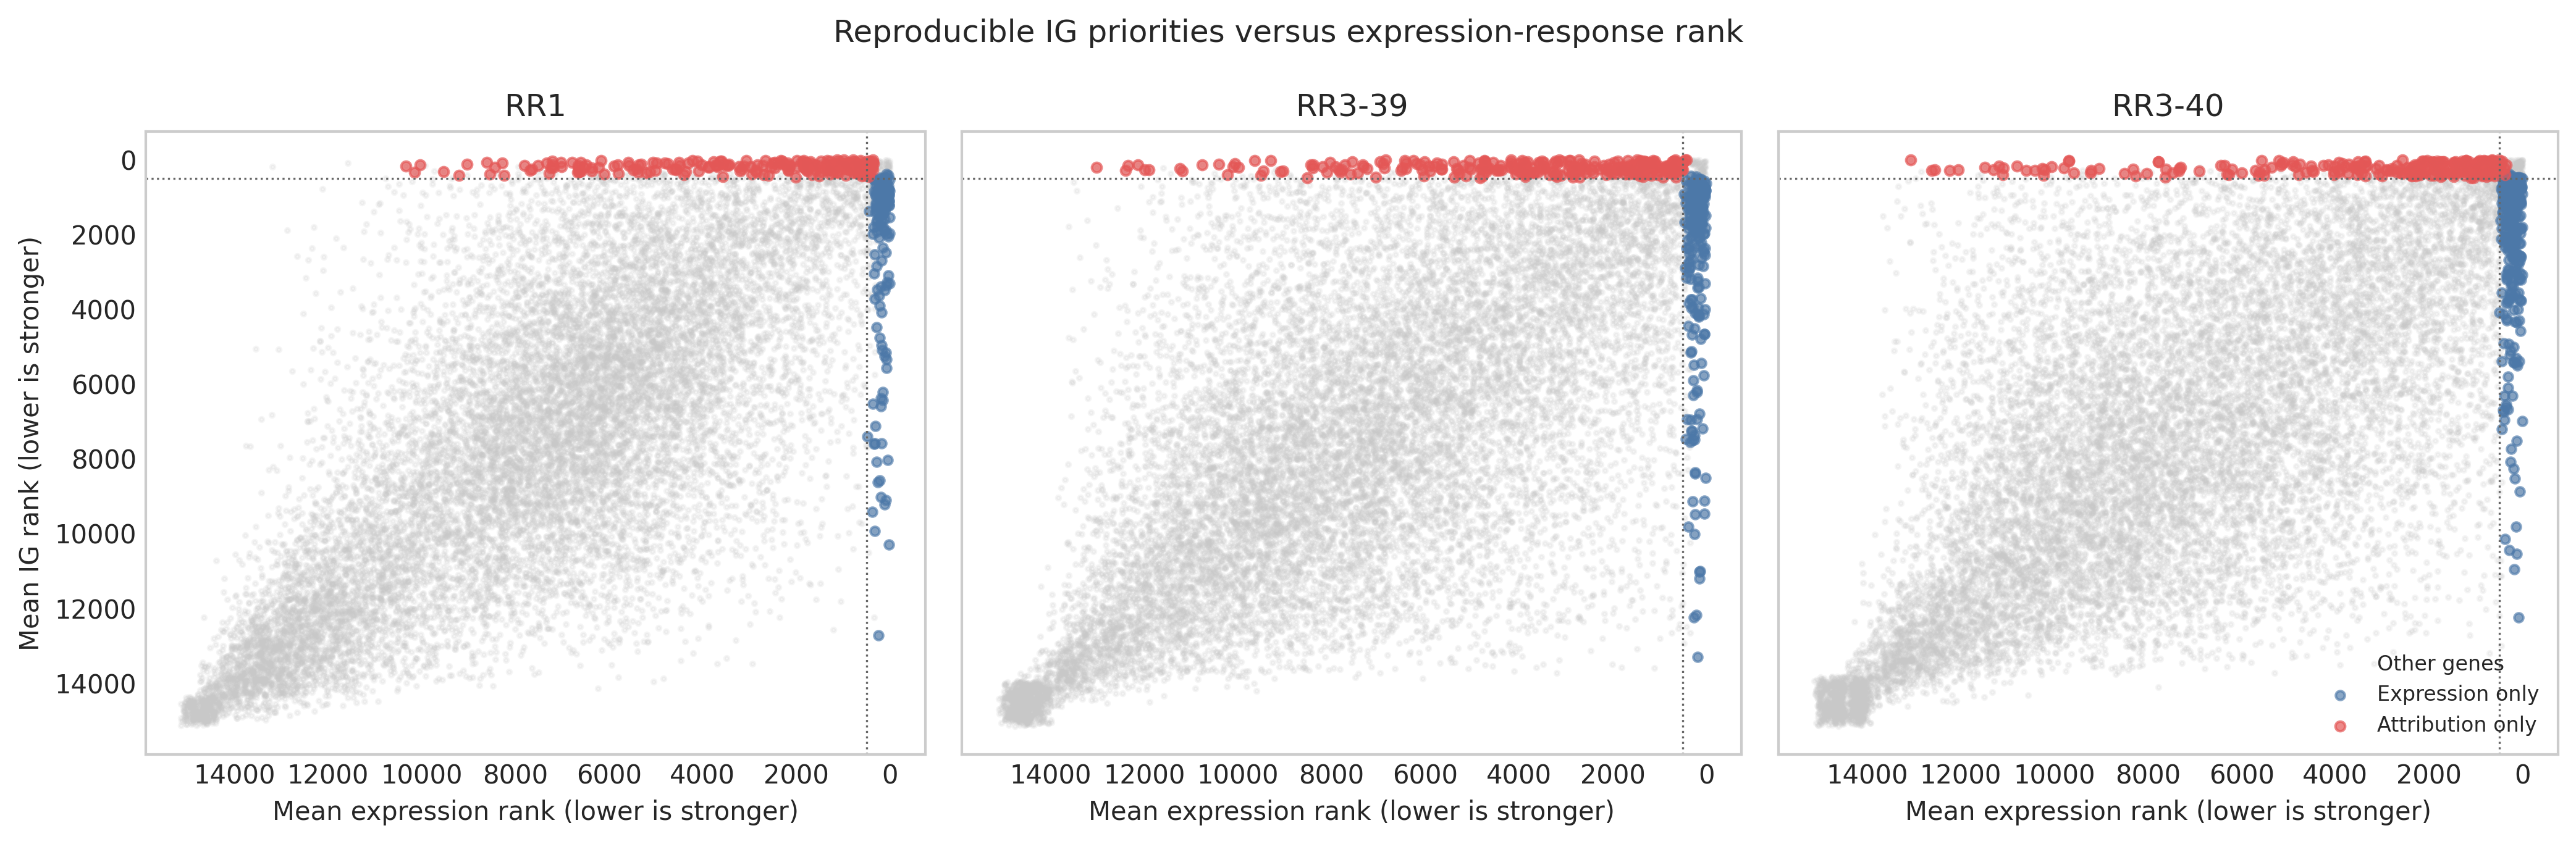

In [12]:
ae = pd.read_csv(R/'summary/attribution_vs_expression_summary.csv')
graph = pd.read_csv(R/'summary/attribution_only_graph_support.csv')
shared_attr = pd.read_csv(R/'genes/shared_attribution_only_genes.csv')
display(ae.style.hide(axis='index').format({'median_abs_expression_effect':'{:.3f}','median_expression_rank':'{:.1f}','median_attribution_rank':'{:.1f}'}))
print('Attribution-only genes recurring in ≥2 cohorts:', len(shared_attr))
print('Attribution-only genes recurring in all 3 cohorts:', int((shared_attr.cohort_count == 3).sum()))
rank_cols=[c for c in shared_attr if c.endswith('_attribution_rank_mean')]
shared_attr['mean_available_IG_rank']=shared_attr[rank_cols].mean(axis=1,skipna=True)
display(shared_attr.sort_values(['cohort_count','mean_available_IG_rank'],ascending=[False,True]).head(25).style.hide(axis='index').format(precision=1,na_rep='—'))
display(Image(filename=str(R/'figures/attribution_vs_expression_rank.png'), width=1100))

Attribution-only genes have substantially smaller conventional expression effects and much poorer expression ranks than robust-expression genes, by construction, while retaining strong reproducible IG ranks. There are 200, 271, and 247 attribution-only genes in RR1, RR3-39, and RR3-40; 152 recur in at least two cohorts and 37 recur in all three.

### Biological coherence and contextual-graph support

cohort,gene_set,term,overlap,set_size,fdr
RR1,attribution_only,Hallmark: Xenobiotic Metabolism,23,179,3.21e-13
RR1,attribution_only,Hallmark: Bile Acid Metabolism,14,106,1.14e-07
RR1,attribution_only,GO BP: Cholesterol Efflux (GO:0033344),6,22,2.08e-04
RR1,attribution_only,Hallmark: mTORC1 Signaling,13,179,3.29e-04
RR1,attribution_only,GO BP: Nicotinamide Nucleotide Metabolic Process (GO:0046496),7,40,3.29e-04
RR1,attribution_only,KEGG: GLYOXYLATE AND DICARBOXYLATE METABOLISM,6,28,4.27e-04
RR1,attribution_only,KEGG: BILE SECRETION,8,62,4.27e-04
RR1,attribution_only,KEGG: CHOLESTEROL METABOLISM,7,45,4.74e-04
RR1,attribution_only,Hallmark: Complement,12,169,5.63e-04
RR1,attribution_only,Hallmark: Pperoxisome,9,94,8.34e-04


cohort,gene_set,genes,graph_supported,graph_support_fraction,median_graph_local_cosine
RR1,Attribution only,200,20,10.0%,0.277
RR1,Expression only,133,48,36.1%,0.499
RR1,Robust expression (all),179,74,41.3%,0.521
RR3-39,Attribution only,271,17,6.3%,0.546
RR3-39,Expression only,201,26,12.9%,0.655
RR3-39,Robust expression (all),262,41,15.6%,0.705
RR3-40,Attribution only,247,23,9.3%,0.705
RR3-40,Expression only,271,39,14.4%,0.799
RR3-40,Robust expression (all),381,70,18.4%,0.818


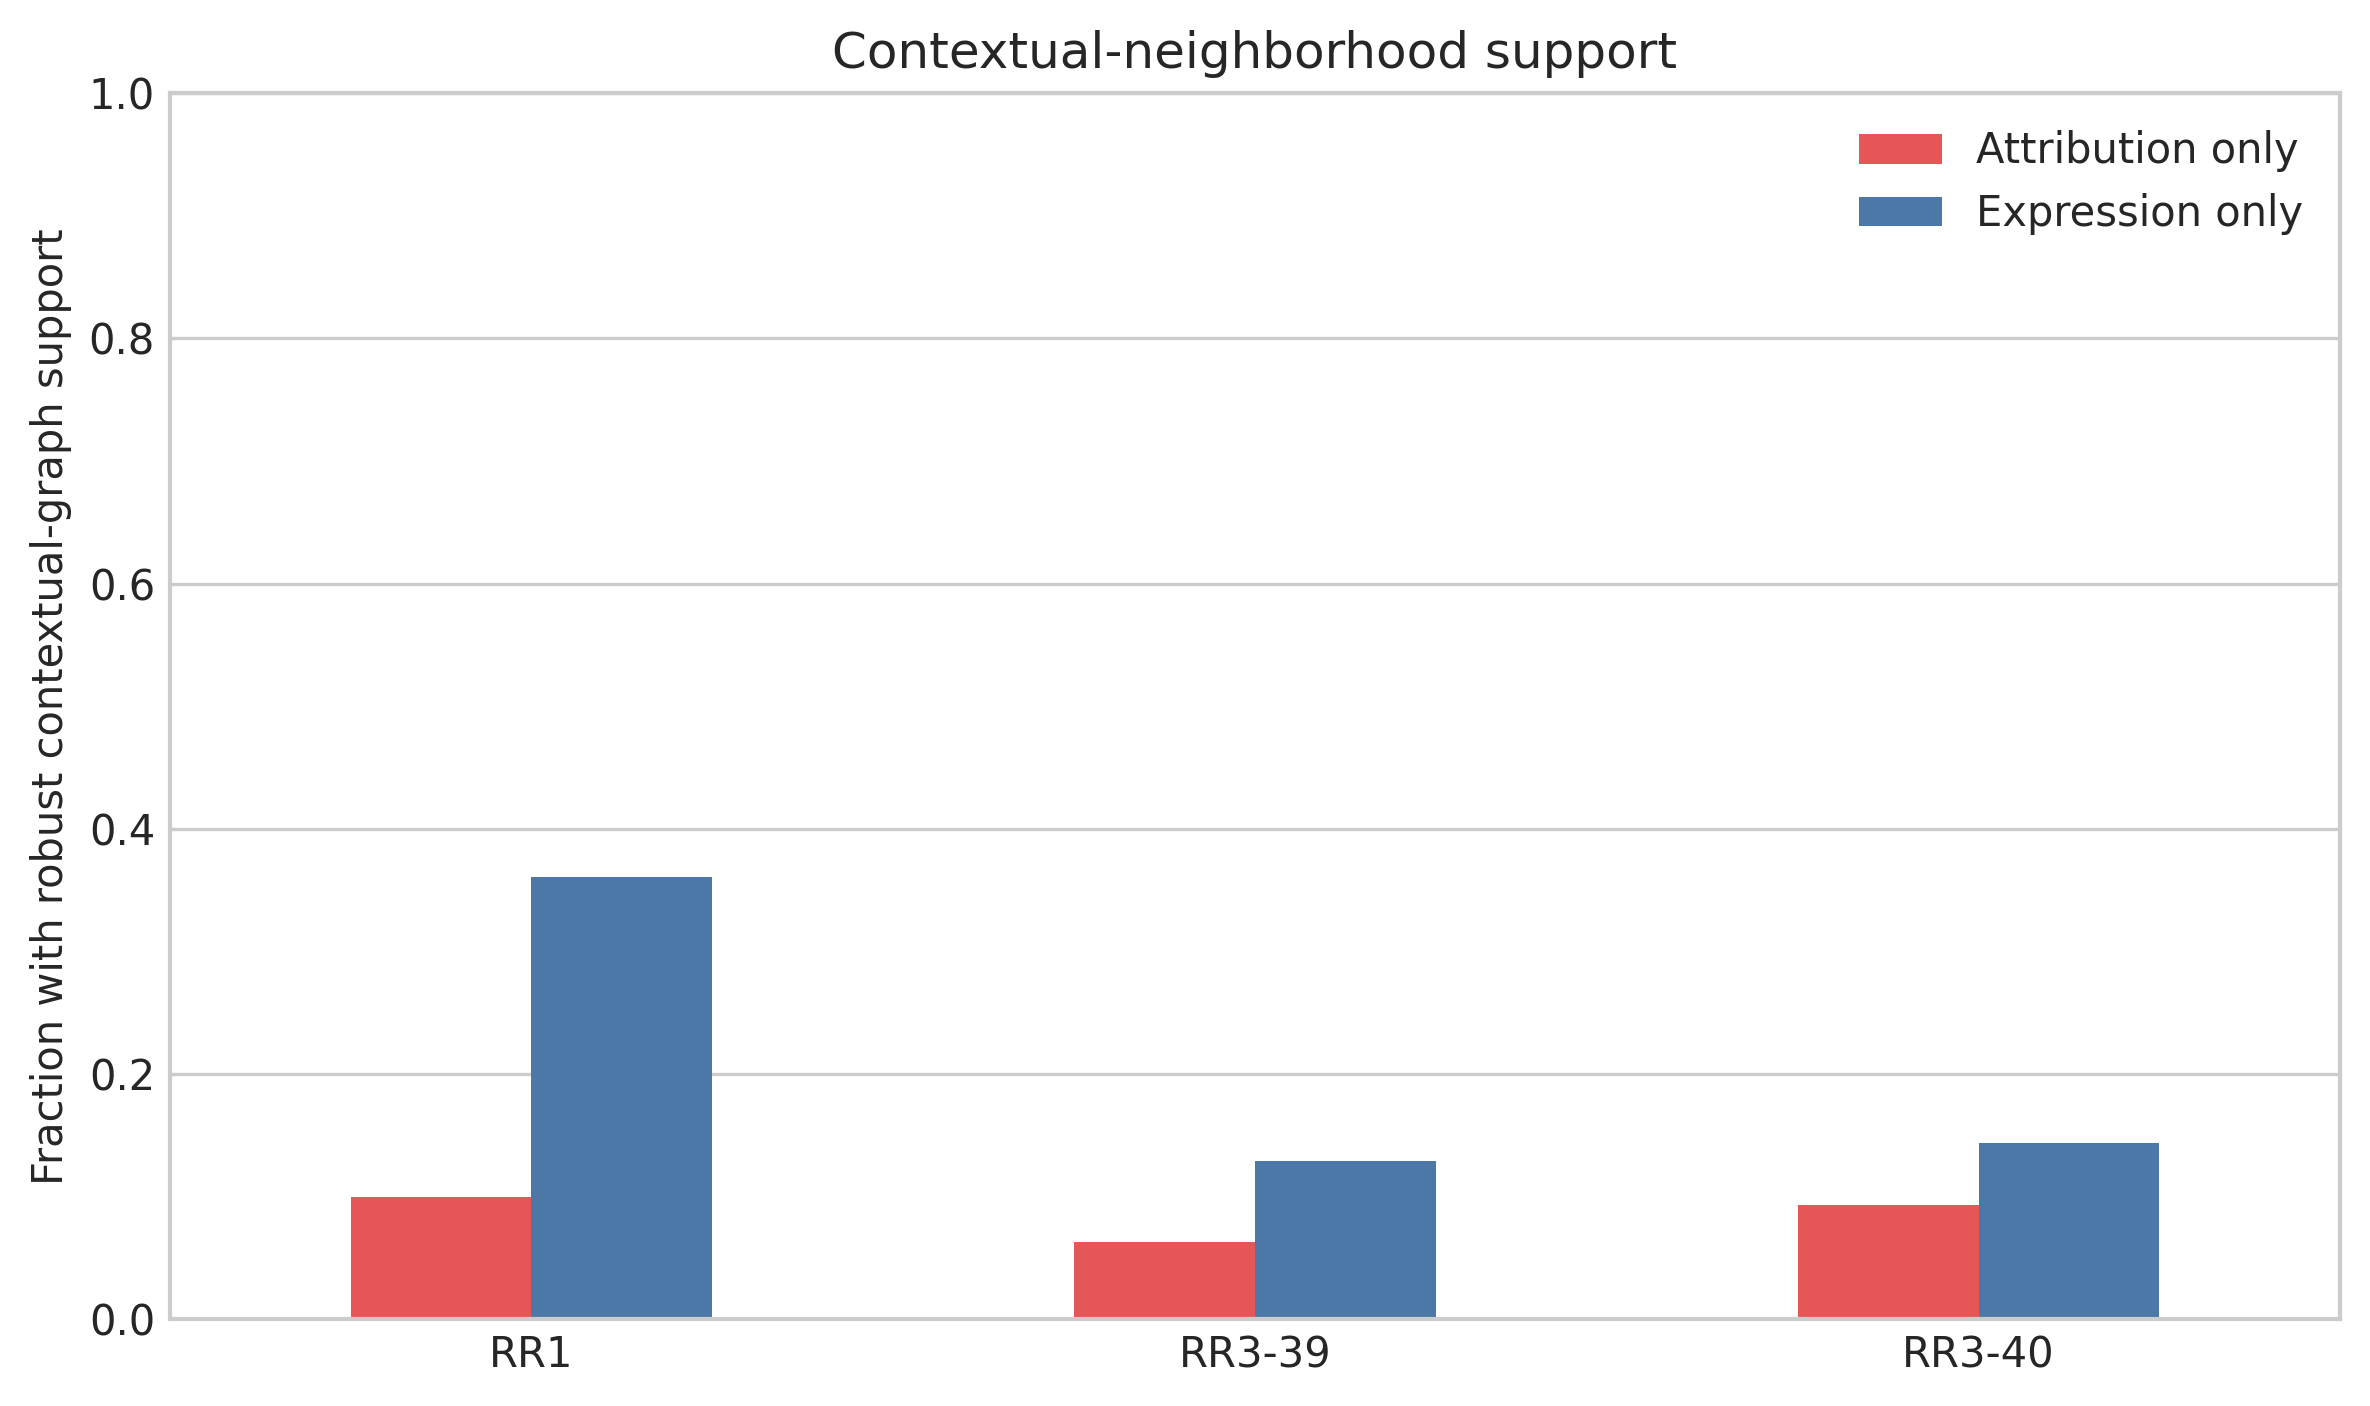

analysis,compatible,reason
Existing IG deletion cross-reference,False,"Existing deletion sweeps validate mode-level IG-ranked panels, not these cohort-specific technically reproducible attribution-only sets; no gene-set-specific causal deletion claim is made."


In [13]:
enr = pd.read_csv(R/'pathways/attribution_only_enrichment.csv')
display(enr.query('fdr < 0.05').sort_values(['cohort','fdr']).groupby('cohort').head(10)[['cohort','gene_set','term','overlap','set_size','fdr']].style.hide(axis='index').format({'fdr':'{:.2e}'}))
display(graph.style.hide(axis='index').format({'graph_support_fraction':'{:.1%}','median_graph_local_cosine':'{:.3f}'}))
display(Image(filename=str(R/'figures/attribution_only_graph_support.png'), width=800))
display(pd.read_csv(R/'summary/deletion_compatibility.csv').style.hide(axis='index'))

The attribution-only sets are biologically coherent: xenobiotic and bile-acid metabolism recur prominently, with lipid/fatty-acid, amino-acid/catabolic, complement, peroxisomal, and oxidative-phosphorylation programs varying by cohort. The ≥2-cohort set is likewise enriched for xenobiotic metabolism, adipogenesis, complement, bile-acid metabolism, and NAD(P)-related metabolism.

However, contextual-graph confirmation is **not stronger** for attribution-only genes: only 10.0% (RR1), 6.3% (RR3-39), and 9.3% (RR3-40) meet the stringent robust-graph criterion, versus 36.1%, 12.9%, and 14.4% of expression-only genes. Existing deletion sweeps targeted different mode-level IG rankings and cannot validate these exact gene sets.

**Scientist-facing conclusion:** BridgeRNA consistently prioritizes a recurrent, pathway-coherent set of genes that conventional response magnitude does not rank highly. This is evidence of additional model-derived ranking structure, especially around hepatic xenobiotic, bile-acid, lipid, and amino-acid metabolism. The sparse graph support and lack of a compatible attribution-only deletion test prevent the stronger claim that these genes constitute a separately validated causal response program.

## 9. Direct answers

1. **How much RR1 survives?** A restricted core survives: 179 expression genes, 246 IG genes, 476 positive local graph neighborhoods, 114 genes supported by ≥2 levels, and 26 by all three. Its global and Hallmark response directions do not reproduce.
2. **Compared with RR3?** RR3-40 is strongest (381 expression genes; 172 ≥2-level; 31 all-three), followed by RR3-39 at the global/pathway scales. RR1 is markedly less reproducible.
3. **Is RR1 uniquely splicing-sensitive?** It is the clearest cohort for measurement-sensitive mRNA processing/splicing enrichment. Related terms occur elsewhere, so “unique” should not be interpreted as exclusive biology.
4. **What is robust in all three?** Five multiscale genes and 22 T-cell-independent signed-IG pathway profiles, centered on lipid/carnitine/bile and central-carbon metabolism, stress responses, immune/complement regulation, transport, and metabolic transcription.
5. **What is cohort-specific?** 90 RR1-only, 75 RR3-39-only, and 134 RR3-40-only ≥2-level genes under these definitions; these may reflect duration, cohort, or protocol.
6. **Does attribution identify a more stable subset than expression alone?** It supplies orthogonal model evidence and narrows candidates through intersections, but RR1 attribution ranks themselves are weakly reproducible; it does not simply outperform expression.
7. **Does the graph add confirmation?** Yes, at the gene-neighborhood level, but median local agreement remains much lower in RR1 (0.138) than RR3-39/40 (0.340/0.386).
8. **Why does RR3-40 reproduce better?** Numerically it is more concordant at expression, global latent, Hallmark, graph, and pathway levels. The benchmark establishes this association, not a causal mechanism.
9. **Is RR1 failure technical or biological?** Mixed. It coincides with a major protocol transition and strong measurement-sensitive programs, while a smaller concordant biological core remains.
10. **What remains defensible?** A restricted multiscale gene core plus a T-cell-independent signed-IG pathway core involving lipid/carnitine/bile and central-carbon metabolism, stress responses, immune/complement regulation, transport, and metabolic transcription. Claims should remain at the level of concordant attribution.

## Scientist-facing synthesis

1. **Conventional analysis established** that RR3-40 is the strongest technical replication, RR3-39 also reproduces well, and RR1 is substantially more measurement-sensitive. Conventional matched expression retains a restricted RR1 core and suggests exploratory RR1/RR3 directional opposition, but the opposition is weaker in full-stratum edgeR and is therefore estimator-dependent.
2. **BridgeRNA added** reproducible gene-importance and contextual-neighborhood evidence beyond marginal expression ranking. A T-cell-independent signed-IG pathway analysis identifies 22 profiles conserved across all three technical comparisons; robust-gene enrichment independently reinforces lipid/carnitine/bile metabolism across all three and selected immune or stress programs in individual cohorts.
3. **The robust biological conclusion** is that metabolic, stress-response, immune/complement, transport, and regulatory programs retain concordant BridgeRNA attribution across technical remeasurement, while RR1 preserves a much narrower multiscale response than RR3. These are technically reproducible representations—not proof of causal spaceflight pathways or protocol-independent biology.

## 10. Native-transcriptome sensitivity analysis

This final conventional control asks whether restricting RNA-seq analysis to BridgeRNA's 15,165-gene vocabulary materially changes the RR1/RR3 conclusions. It uses raw counts and the exact matched animals for each original/OSD-168 technical-remeasurement pair. edgeR and ranked GSEA are run separately in (1) each dataset's fullest mapped native gene universe and (2) the Bridge vocabulary. BridgeRNA embeddings and IG are not involved.

Because PolyA and ribodepletion expose different measurable transcript populations, the native arms retain their own expression-filtered gene sets. Response reproducibility is therefore computed over genes tested in both measurements within each cohort and universe.

OSD,source_rows,mapped_rows,native_unique_symbols,samples,source_file
OSD-48,57186,56642,56404,9,data/osdr/raw/replaced_star_supplementary/GLDS-48_rna_seq_STAR_Unnormalized_Counts_GLbulkRNAseq.csv
OSD-168,55628,51486,51432,17,data/osdr/raw/GLDS-168_rna_seq_Unnormalized_Counts.csv
OSD-137,55536,51486,51432,8,data/osdr/raw/GLDS-137_rna_seq_Unnormalized_Counts.csv


cohort,gene_universe,common_tested_genes,cosine,spearman,direction_agreement,pathways_compared,NES_spearman,robust_pathways,reversing_pathways,significant_original,significant_remeasurement
RR1,native,13678,0.621,0.506,67.1%,4615,0.494,5,9,85,494
RR3-39,native,15317,0.610,0.598,74.6%,4724,0.786,248,1,322,403
RR3-40,native,15362,0.562,0.613,76.2%,4714,0.873,43,0,110,62
RR1,bridge_vocab,10587,0.713,0.568,69.1%,4426,0.523,15,0,87,260
RR3-39,bridge_vocab,11140,0.663,0.627,74.9%,4567,0.782,230,1,307,362
RR3-40,bridge_vocab,11073,0.691,0.674,78.0%,4548,0.871,65,0,121,75


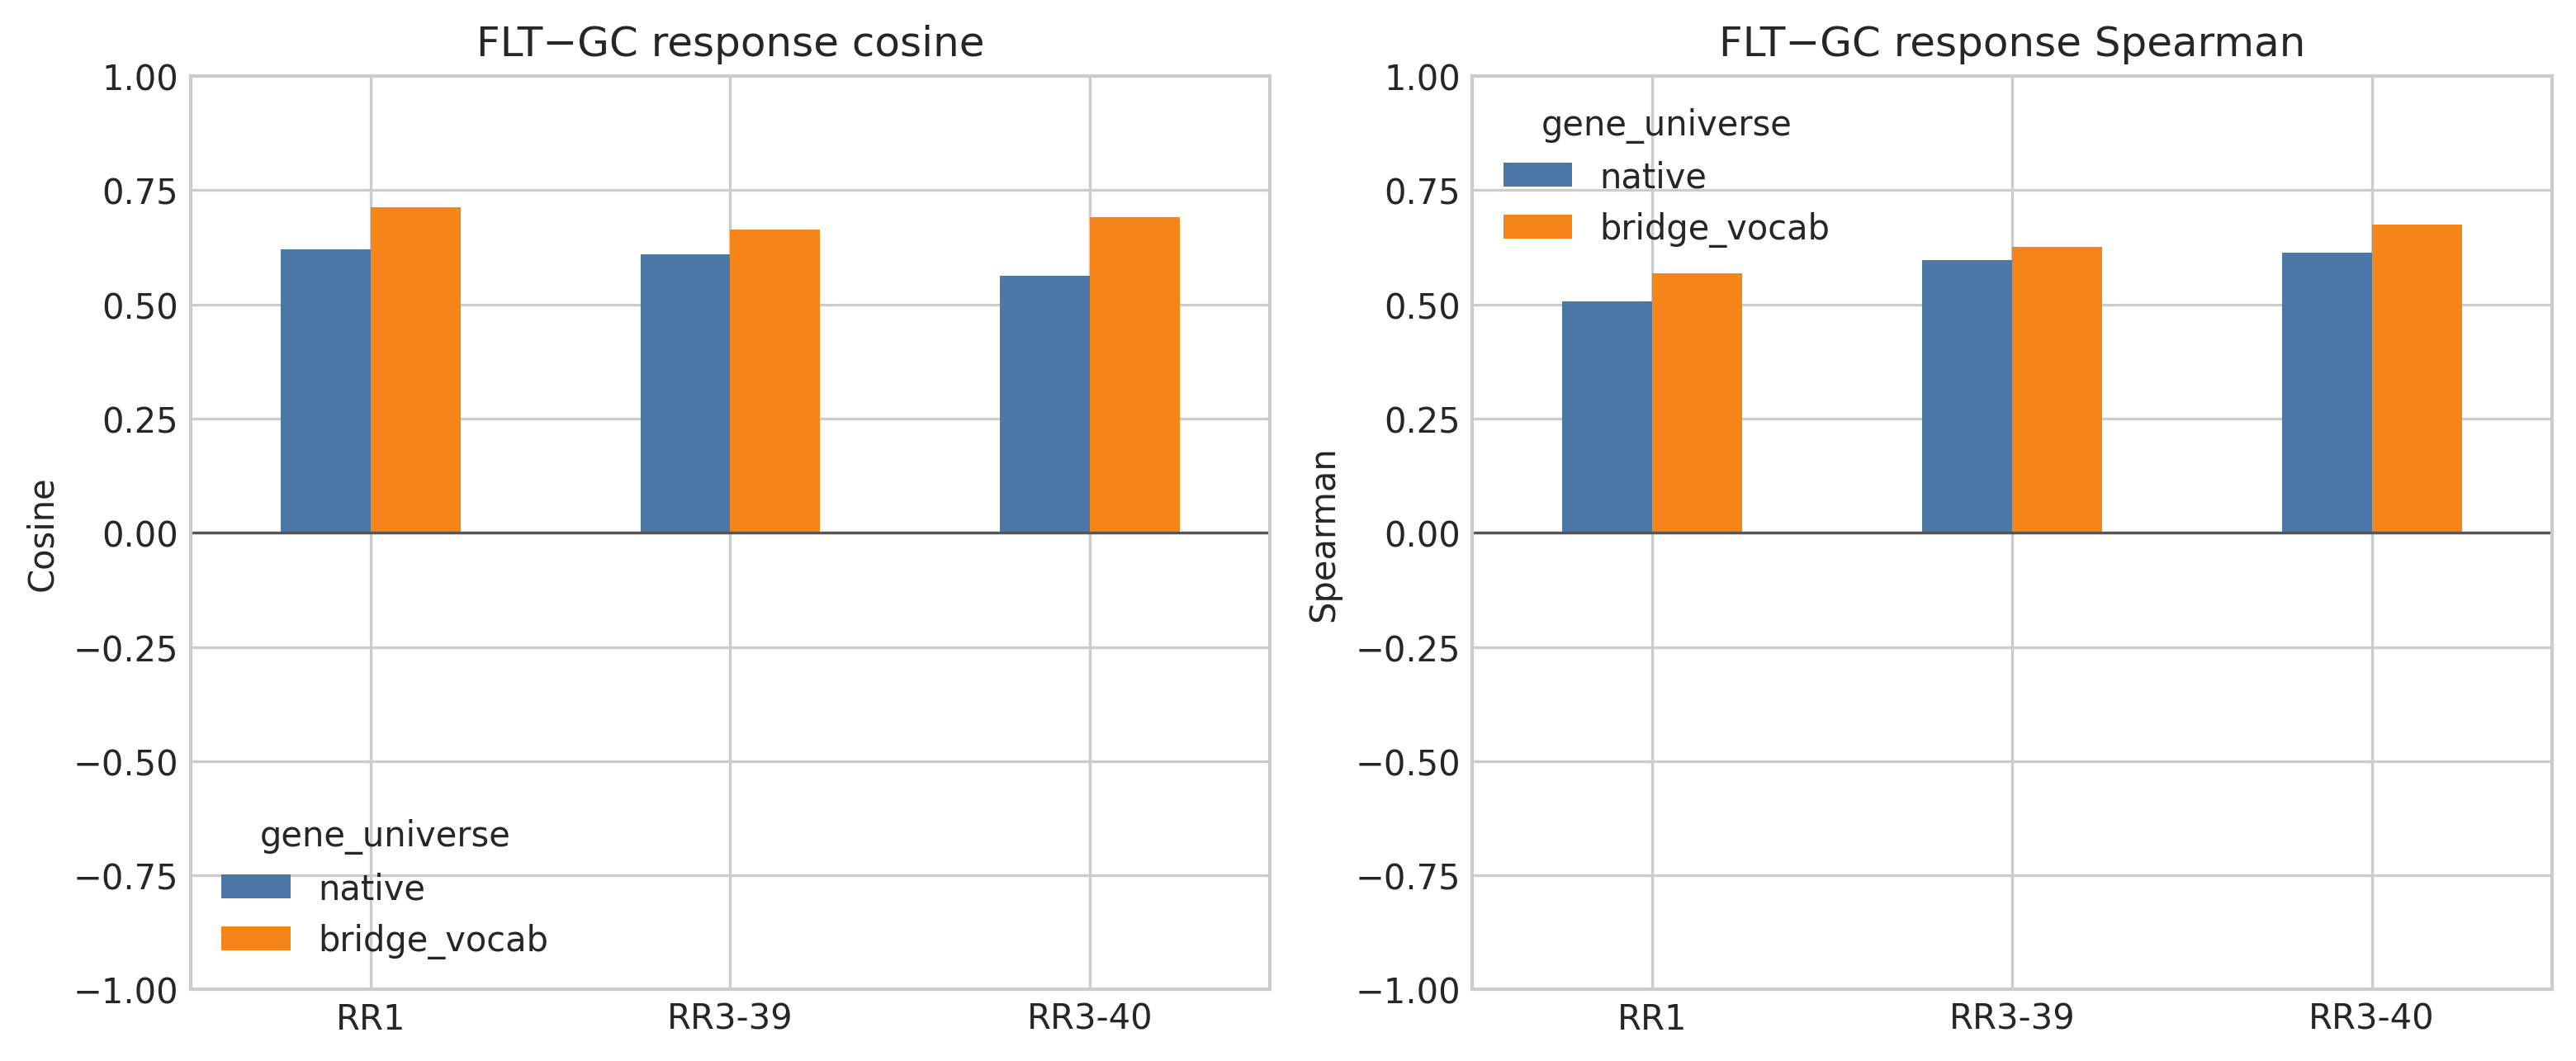

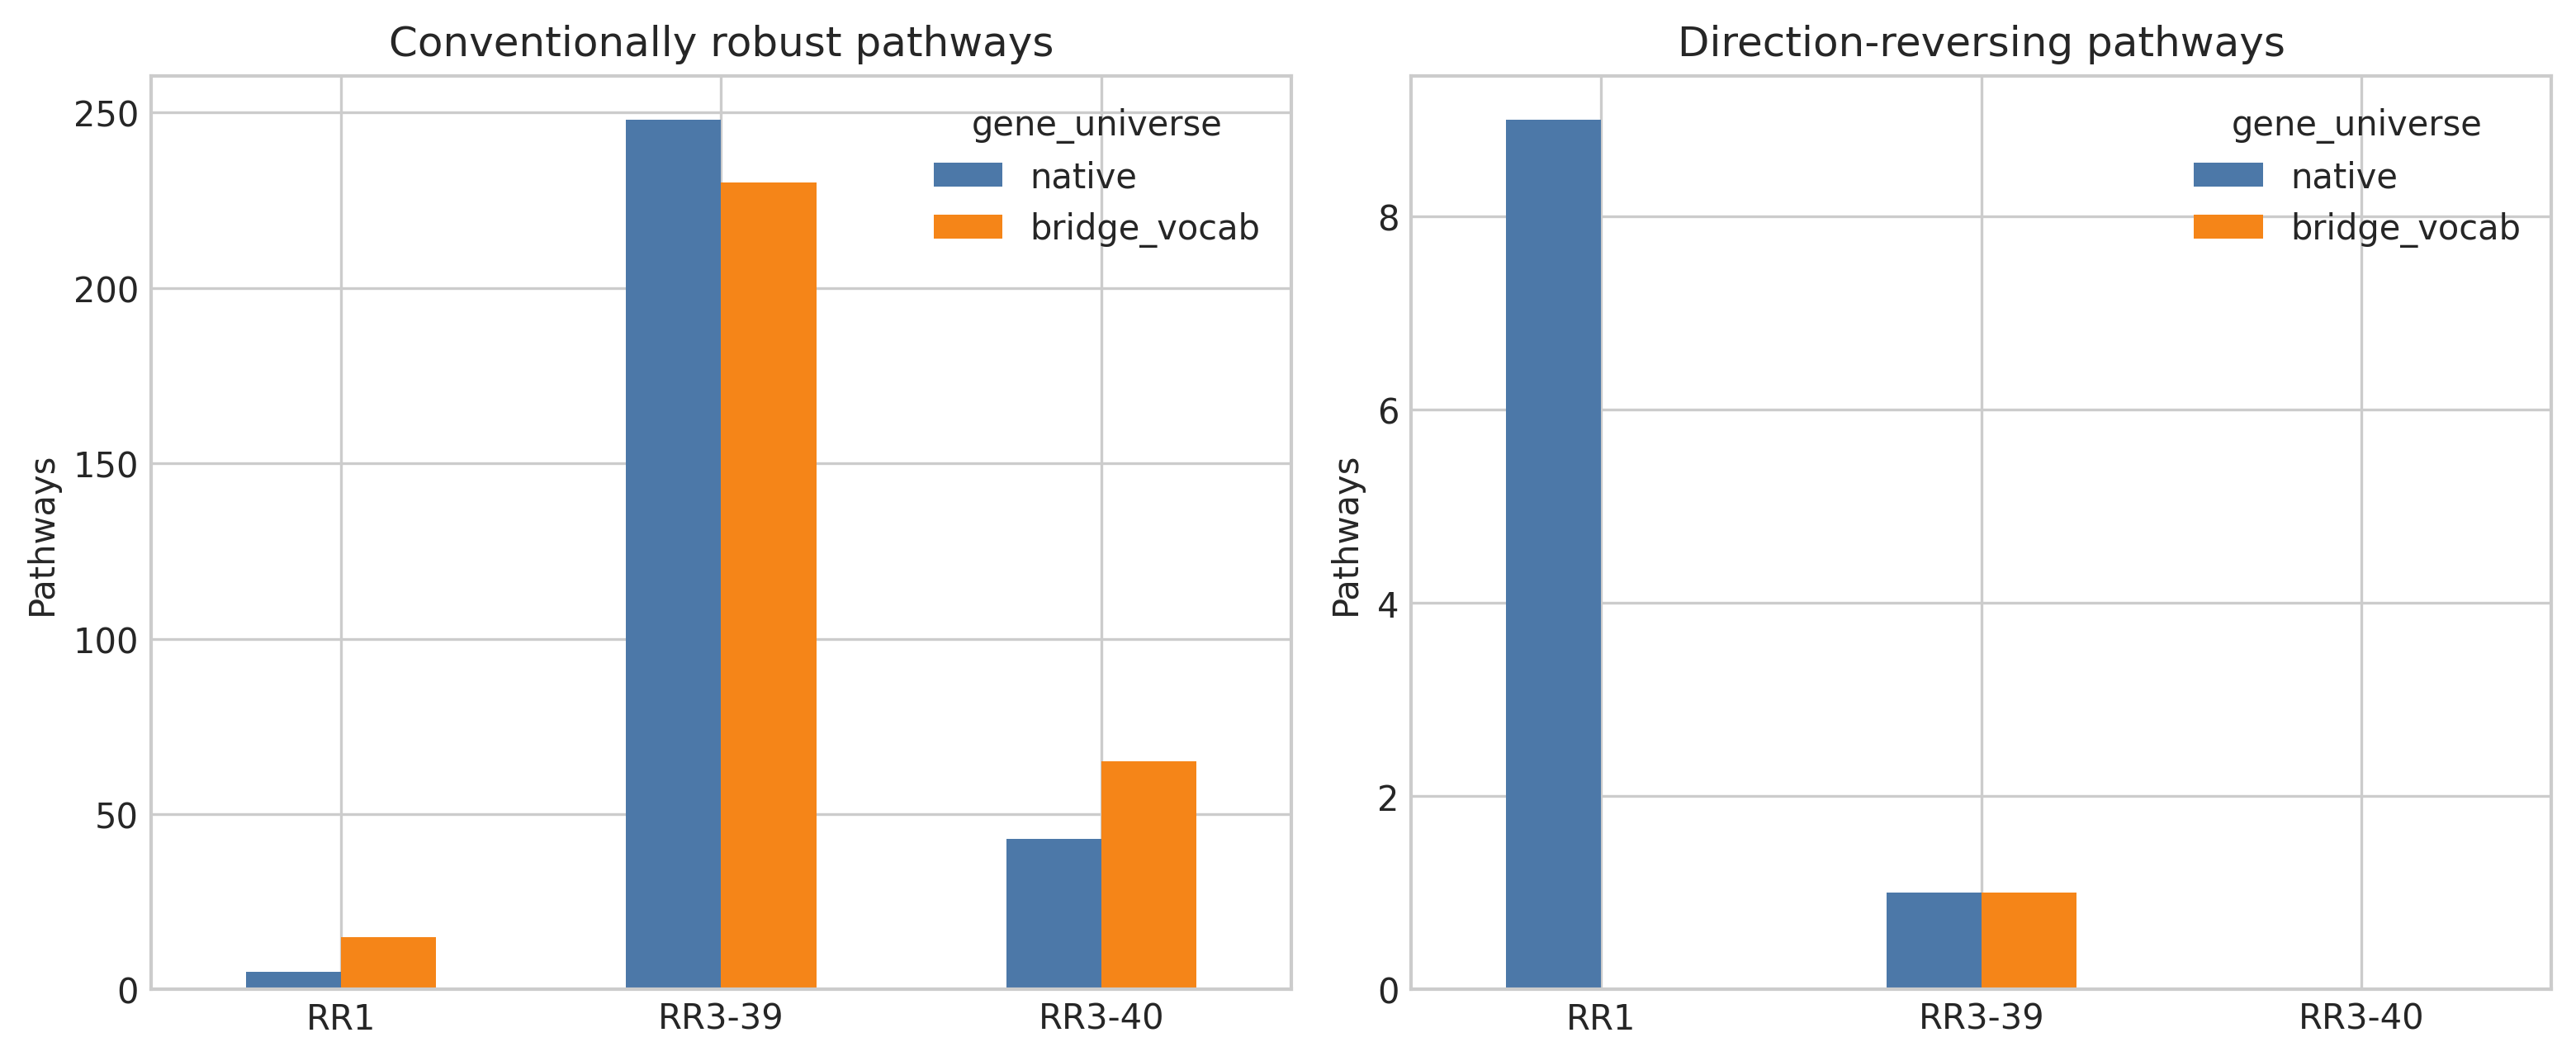

In [14]:
N = R/'native_transcriptome_sensitivity'
native = pd.read_csv(N/'primary_summary.csv')
audit = pd.read_csv(N/'native_gene_audit.csv')
display(audit.style.hide(axis='index'))
display(native.style.hide(axis='index').format({'cosine':'{:.3f}','spearman':'{:.3f}','direction_agreement':'{:.1%}','NES_spearman':'{:.3f}'}))
display(Image(filename=str(N/'expression_reproducibility_native_vs_vocab.png'), width=900))
display(Image(filename=str(N/'pathway_reproducibility_native_vs_vocab.png'), width=900))

### Direct gene-universe comparison

For the compact table, a `GSEA hit` is deliberately stringent: the pathway must have FDR < 0.05 in both the original and remeasurement and retain the same NES direction. `Gained` and `lost` therefore describe changes in this protocol-robust conventional set—not every isolated significance call.

Cohort,Native_genes,Native_GSEA_hits,"15,165 GSEA hits",Shared_hits,Gained_by_restriction,Lost_by_restriction,Pathway_Jaccard,IG-core overlap
RR1,13678,5,15,3,12,2,0.176,0
RR3-39,15317,248,230,219,11,29,0.846,2
RR3-40,15362,43,65,38,27,5,0.543,0


Cohort,Native_DE_genes_original,Native_DE_genes_remeasurement,Bridge_vocab_DE_genes_original,Bridge_vocab_DE_genes_remeasurement,NES_Spearman_original,NES_Spearman_remeasure,FDR_Spearman_original,FDR_Spearman_remeasure,Direction_reversals_between_universes
RR1,129,1964,104,815,0.966,0.934,0.905,0.366,0
RR3-39,0,1,0,0,0.969,0.969,0.908,0.868,0
RR3-40,33,8,41,23,0.964,0.965,0.867,0.832,0


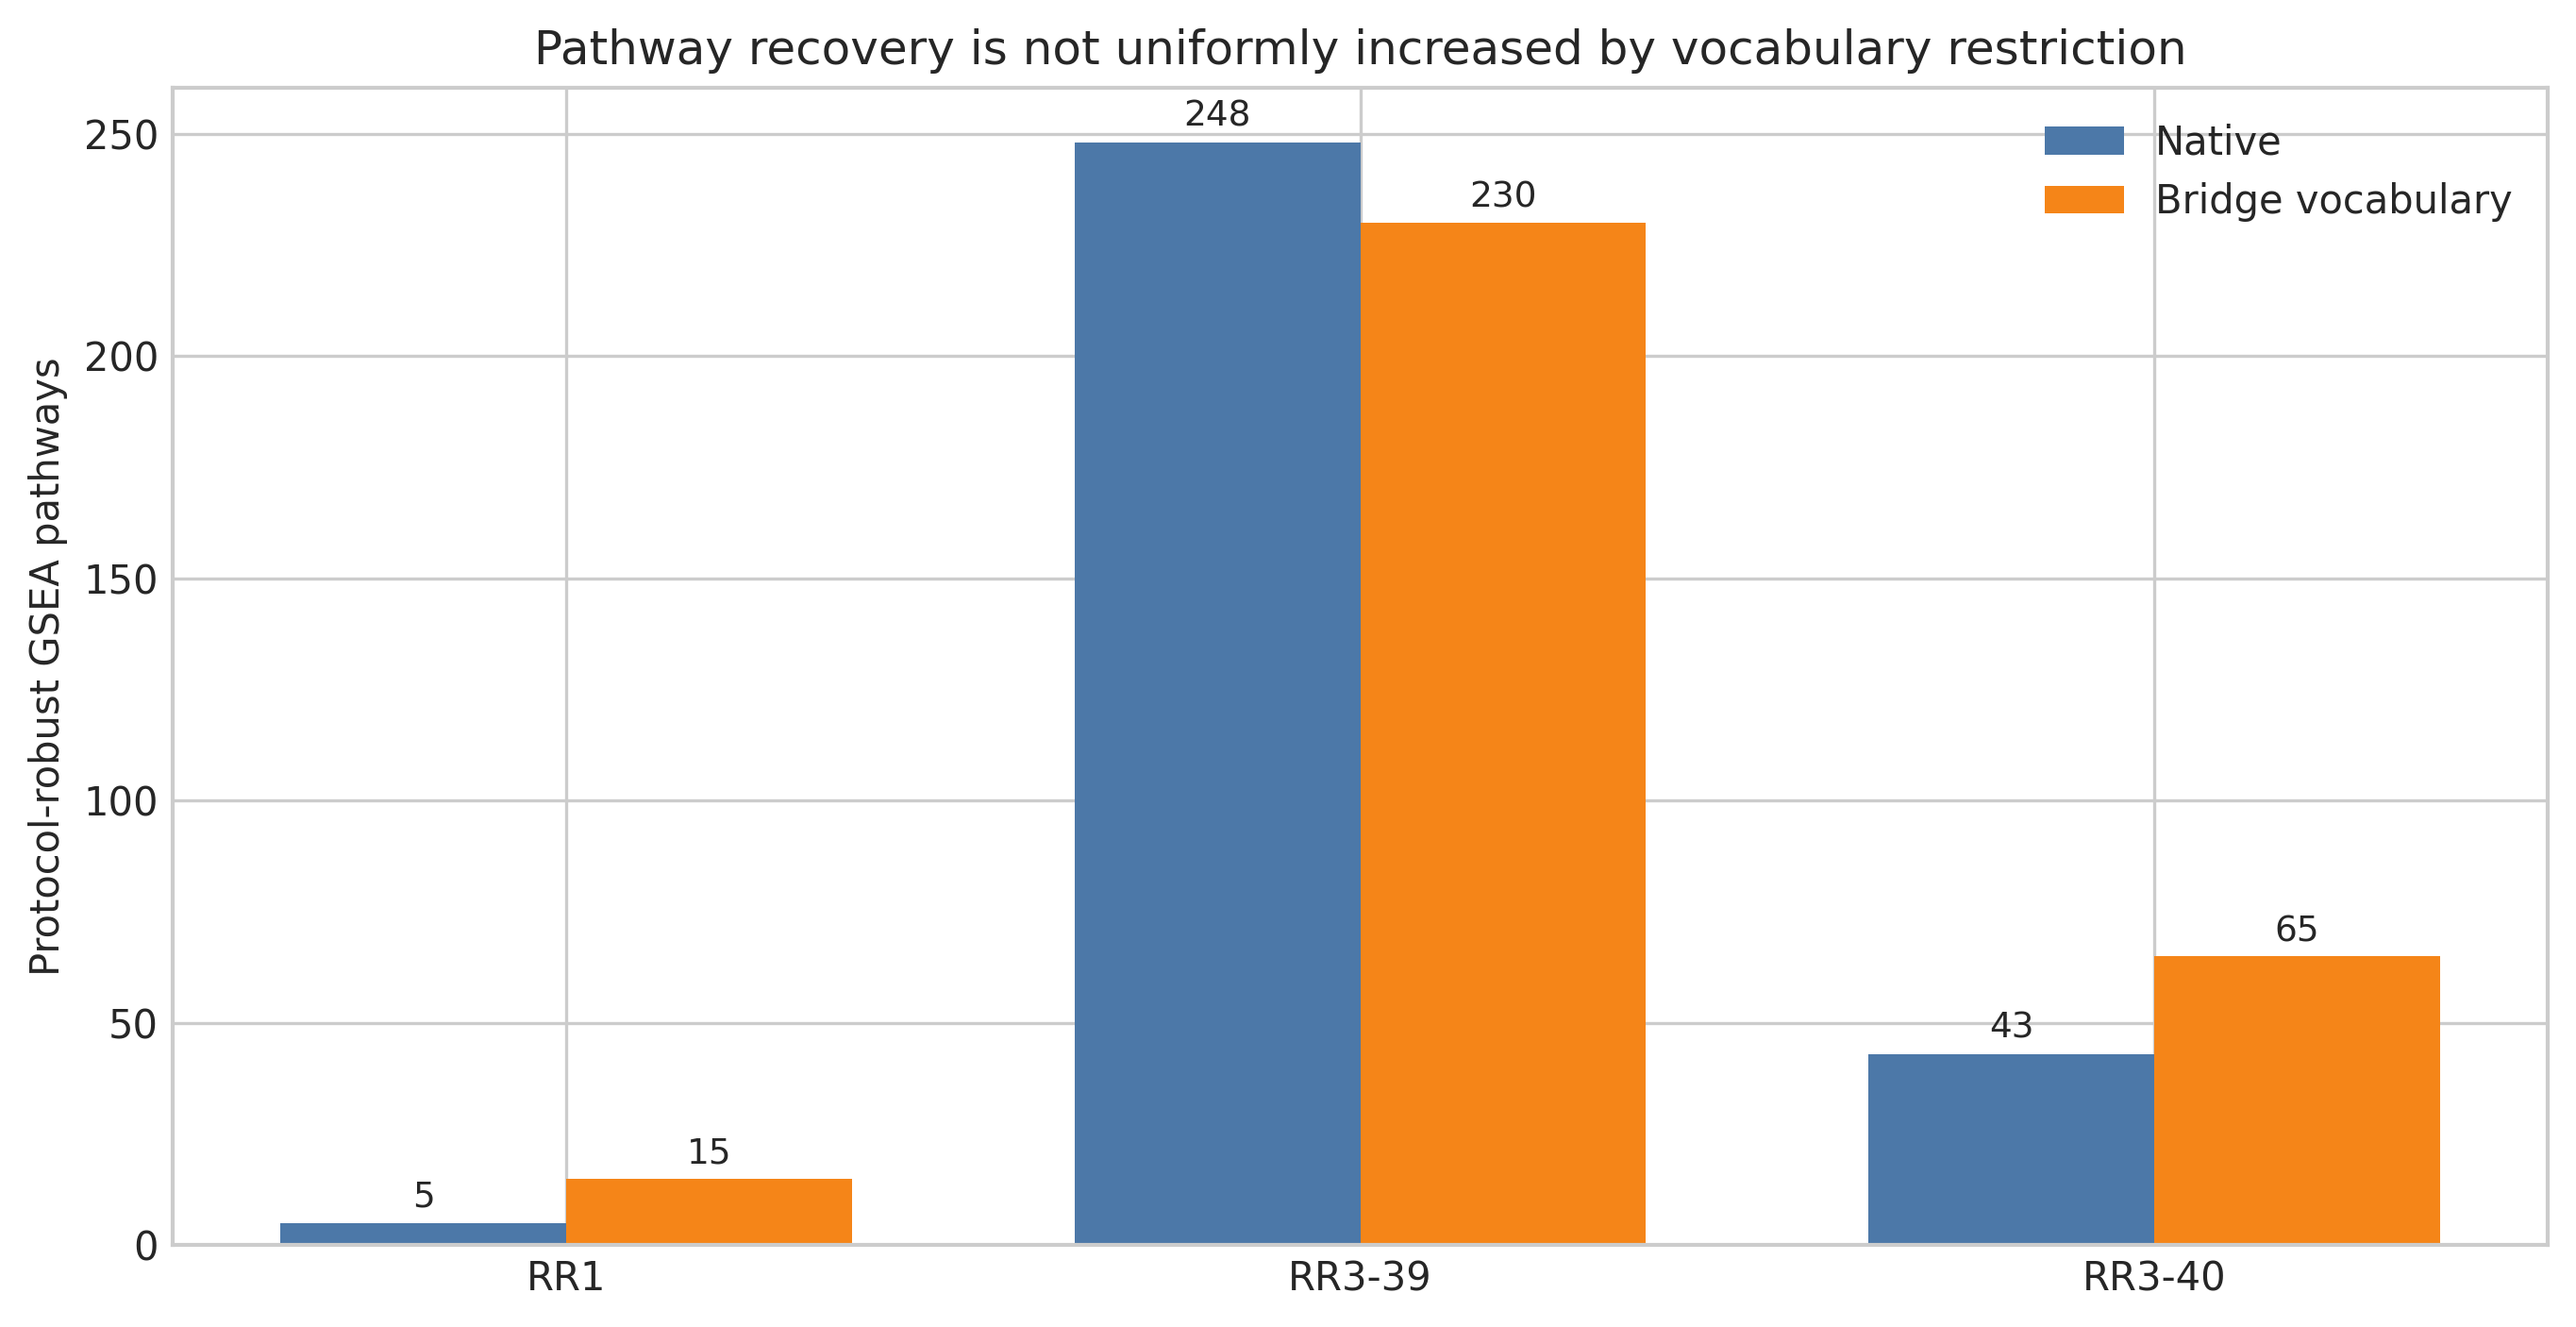

cohort,status,source,pathway,in_IG_core_22
RR1,gained_by_restriction,GO:BP,Cholesterol Biosynthetic Process (GO:0006695),False
RR1,gained_by_restriction,GO:BP,Negative Regulation of Innate Immune Response (GO:0045824),False
RR1,gained_by_restriction,GO:BP,Negative Regulation of Viral Genome Replication (GO:0045071),False
RR1,gained_by_restriction,GO:BP,Negative Regulation of Viral Process (GO:0048525),False
RR1,gained_by_restriction,GO:BP,Secondary Alcohol Biosynthetic Process (GO:1902653),False
RR1,gained_by_restriction,GO:BP,Signal Transduction in Response to DNA Damage (GO:0042770),False
RR1,gained_by_restriction,GO:BP,Sterol Biosynthetic Process (GO:0016126),False
RR1,gained_by_restriction,REAC,Activation of Gene Expression by SREBF (SREBP),False
RR1,gained_by_restriction,REAC,Cholesterol Biosynthesis,False
RR1,gained_by_restriction,REAC,DDX58 IFIH1-mediated Induction of Interferon-Alpha Beta,False


In [15]:
universe = pd.read_csv(N/'gene_universe_summary.csv')
compact = universe[['Cohort','Native_genes','Native_GSEA_hits','Bridge_vocab_GSEA_hits','Shared_hits','Gained_by_restriction','Lost_by_restriction','Pathway_Jaccard','Native_IG_core_overlap']].rename(columns={'Bridge_vocab_GSEA_hits':'15,165 GSEA hits','Native_IG_core_overlap':'IG-core overlap'})
display(compact.style.hide(axis='index').format({'Pathway_Jaccard':'{:.3f}'}))
de_counts = universe[['Cohort','Native_DE_genes_original','Native_DE_genes_remeasurement','Bridge_vocab_DE_genes_original','Bridge_vocab_DE_genes_remeasurement','NES_Spearman_original','NES_Spearman_remeasure','FDR_Spearman_original','FDR_Spearman_remeasure','Direction_reversals_between_universes']]
display(de_counts.style.hide(axis='index').format({c:'{:.3f}' for c in de_counts.columns if 'Spearman' in c}))
display(Image(filename=str(N/'robust_gsea_hits_by_gene_universe.png'), width=850))
changes = pd.read_csv(N/'pathway_gained_lost_shared.csv')
display(changes.query("status != 'shared'").groupby(['cohort','status']).head(10).style.hide(axis='index'))

### The 22 signed-IG pathways under the native conventional universe

This table tests the already frozen 22-pathway set against conventional GSEA in the original and remeasurement separately. It does not use conventional results to redefine the set.

In [16]:
support22 = pd.read_csv(N/'signed_ig_22_conventional_support.csv')
rows=[]
for _,q in support22.iterrows():
    row={'Module':q.module,'Pathway':q.pathway}
    for cohort,key in [('RR1','RR1'),('RR3-39','RR3_39'),('RR3-40','RR3_40')]:
        for universe,label in [('native','Native'),('bridge_vocab','Bridge vocab')]:
            ok=(q[f'{universe}_{key}_original_FDR']<.05 and q[f'{universe}_{key}_remeasure_FDR']<.05 and q[f'{universe}_{key}_original_NES']*q[f'{universe}_{key}_remeasure_NES']>0)
            row[f'{cohort} {label}']='robust' if ok else 'not robust'
    rows.append(row)
display(pd.DataFrame(rows).style.hide(axis='index'))
native_only = pd.read_csv(N/'native_only_significant_pathways.csv.gz')
native_only_counts = native_only.groupby(['cohort','measurement']).size().rename('native-only significant pathways').reset_index()
display(native_only_counts.style.hide(axis='index'))
display(native_only.sort_values(['cohort','measurement','fdr_native']).groupby(['cohort','measurement']).head(5)[['cohort','measurement','source','pathway','nes_native','fdr_native','nes_bridge_vocab','fdr_bridge_vocab']].style.hide(axis='index').format({'nes_native':'{:+.3f}','fdr_native':'{:.2e}','nes_bridge_vocab':'{:+.3f}','fdr_bridge_vocab':'{:.2e}'},na_rep='not tested'))

Module,Pathway,RR1 Native,RR1 Bridge vocab,RR3-39 Native,RR3-39 Bridge vocab,RR3-40 Native,RR3-40 Bridge vocab
"Lipid, carnitine, and bile metabolism",Carnitine Metabolic Process (GO:0009437),not robust,not robust,not robust,not robust,not robust,not robust
Fluid and water transport,Fluid Transport (GO:0042044),not robust,not robust,not robust,not robust,not robust,not robust
"Lipid, carnitine, and bile metabolism",Intracellular Lipid Transport (GO:0032365),not robust,not robust,not robust,not robust,not robust,not robust
Innate immune and complement regulation,Positive Regulation of Immune System Process (GO:0002684),not robust,not robust,not robust,not robust,not robust,not robust
Innate immune and complement regulation,Positive Regulation of Innate Immune Response (GO:0045089),not robust,not robust,not robust,not robust,not robust,not robust
Innate immune and complement regulation,Positive Regulation of Response to Biotic Stimulus (GO:0002833),not robust,not robust,not robust,not robust,not robust,not robust
"Lipid, carnitine, and bile metabolism",Positive Regulation of Triglyceride Metabolic Process (GO:0090208),not robust,not robust,not robust,not robust,not robust,not robust
IGF-receptor signaling,Regulation of Insulin-Like Growth Factor Receptor Signaling Pathway (GO:0043567),not robust,not robust,not robust,not robust,not robust,not robust
"Lipid, carnitine, and bile metabolism",Regulation of Lipid Biosynthetic Process (GO:0046890),not robust,not robust,not robust,not robust,not robust,not robust
Fluid and water transport,Water Transport (GO:0006833),not robust,not robust,not robust,not robust,not robust,not robust


cohort,measurement,native-only significant pathways
RR1,original,12
RR1,remeasure,289
RR3-39,original,43
RR3-39,remeasure,77
RR3-40,original,19
RR3-40,remeasure,17


cohort,measurement,source,pathway,nes_native,fdr_native,nes_bridge_vocab,fdr_bridge_vocab
RR1,original,GO:BP,Defense Response to Virus (GO:0051607),+2.216,1.00e-03,+1.865,1.36e-01
RR1,original,KEGG,INFLUENZA A,+1.925,1.22e-02,+1.745,9.57e-02
RR1,original,KEGG,HEPATITIS C,+1.927,1.52e-02,+1.723,1.02e-01
RR1,original,REAC,tRNA Processing in the Mitochondrion,+1.990,2.22e-02,+1.641,8.96e-02
RR1,original,GO:BP,Positive Regulation of Immune System Process (GO:0002684),+2.042,2.28e-02,+1.687,3.42e-01
RR1,remeasure,GO:BP,"Mitochondrial Electron Transport, Cytochrome C to Oxygen (GO:0006123)",-2.261,1.00e-03,not tested,not tested
RR1,remeasure,GO:BP,Mitochondrion Organization (GO:0007005),-2.229,1.00e-03,-1.769,7.85e-02
RR1,remeasure,GO:BP,Metallo-sulfur Cluster Assembly (GO:0031163),-2.218,1.00e-03,-1.827,5.34e-02
RR1,remeasure,GO:BP,Iron-sulfur Cluster Assembly (GO:0016226),-2.218,1.00e-03,-1.827,5.34e-02
RR1,remeasure,KEGG,PATHWAYS OF NEURODEGENERATION - MULTIPLE DISEASES,-2.083,1.00e-03,-1.549,7.22e-02


**Sensitivity result.** The restricted analysis retains 10,587–11,140 genes common to each paired response, versus 13,678–15,362 in the native analysis. Restriction modestly increases expression-response reproducibility in all three cohorts: cosine changes from 0.621→0.713 (RR1), 0.610→0.663 (RR3-39), and 0.562→0.691 (RR3-40). Rank correlation changes similarly (0.506→0.568, 0.598→0.627, and 0.613→0.674).

The global GSEA response relationship is much less sensitive to vocabulary: original-versus-remeasurement NES Spearman is 0.494 vs 0.523 for RR1, 0.786 vs 0.782 for RR3-39, and 0.873 vs 0.871 for RR3-40 (native vs restricted). Individual significance calls do move. Native/restricted robust-pathway counts are 5/15 for RR1, 248/230 for RR3-39, and 43/65 for RR3-40. Importantly, native RR1 contains nine significant direction-reversing pathways versus zero after restriction, so vocabulary restriction makes RR1 appear somewhat more stable—it does not create its instability.

For the frozen 22 signed-IG pathways, the native analysis provides reproducible conventional support for two pathways, both in RR3-39: **Glycine, Serine and Threonine Metabolism** and **Glyoxylate Metabolism and Glycine Degradation**. The restricted arm retains only the latter. None of the 22 is conventionally robust in RR1 or RR3-40. Thus the principal conclusion—that most of the 22 are reproducible BridgeRNA-prioritized signals rather than conventional GSEA rediscoveries—survives use of the full native transcriptome.

Native-only calls add interpretable detail, including antiviral/immune and mitochondrial RNA processing in RR1 original, mitochondrial/OXPHOS programs in RR1 remeasurement and RR3-39, and xenobiotic/glutathione/steroid/CoA metabolism in RR3-40. They show that vocabulary restriction can hide individual programs and alter thresholded pathway counts. It does **not** materially change the higher-level result: RR1 remains the least conventionally reproducible pair; RR3-39 and RR3-40 retain substantially more coherent pathway-response profiles; and the 22-pathway signed-IG core is not explained by omitting non-Bridge genes.

### Decision

**Vocabulary effect contributes partially, but does not explain BridgeRNA reprioritization.** Restriction changes thresholded recovery non-uniformly: robust GSEA hits increase 5→15 in RR1 and 43→65 in RR3-40, but decrease 248→230 in RR3-39. Therefore there is no general mechanism by which the 15,165-gene universe simply inflates pathway recovery. Native/restricted NES profiles remain strongly correlated within each measurement (0.934–0.969), with zero significant cross-universe NES direction reversals.

Most decisively, native-transcriptome GSEA supports only 2 of the fixed 22 signed-IG pathways as protocol-robust—and both occur in RR3-39—versus 1 under vocabulary restriction. Retaining additional native genes therefore adds one conventional confirmation, but leaves 20/22 without reproducible conventional support. The BridgeRNA pathway core cannot reasonably be attributed to gene-universe restriction alone.

## 11. Limitations and provenance

- OSD-168 is a technical remeasurement, not an independent biological replicate.
- “Protocol-robust” only applies to the compared measurement pair.
- The integrated core counts unweighted agreement across expression, signed input-gene IG, and contextual graph evidence.
- Expression-interaction ORA is restricted to the 15,165-gene universe; it is distinct from full-transcriptome raw-count edgeR/GSEA.
- Pathway-profile scores are reused outputs and should not be described as conventional NES.
- The former 29-pathway/six-module result is a secondary T-cell PolyA/ribo PC1–2 technical-control result, not the primary biological core.
- No causal assignment of RR1 instability to one protocol variable is possible from this comparison.